# Análisis exploratorio para el dashboard de alquiler turístico en Málaga

Este notebook realiza el análisis exploratorio del dataset limpio generado en el notebook de preparación y limpieza de datos.

El objetivo es identificar patrones relevantes para una posible inversión en vivienda turística en Málaga, analizando variables como distrito, precio, ocupación estimada, ingresos estimados, disponibilidad y actividad turística reciente.

Este análisis no pretende decidir directamente dónde comprar una vivienda, sino ofrecer una primera lectura de las zonas que presentan mejores señales para seguir estudiando una posible inversión.

Los resultados obtenidos servirán como base para diseñar el dashboard interactivo en Power BI y seleccionar las métricas más útiles para una audiencia no técnica.


In [25]:
# ============================================================
# 1. CONFIGURACIÓN INICIAL
# ============================================================
# Importamos las librerías necesarias para el análisis exploratorio.
# También definimos la ruta del dataset limpio generado
# en el notebook de preparación de datos.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

ruta_dataset_limpio = Path("../data/processed/listings_malaga_processed.csv")

print("Ruta del dataset limpio:")
print(ruta_dataset_limpio)

print("\n¿Existe el archivo?")
print(ruta_dataset_limpio.exists())

Ruta del dataset limpio:
..\data\processed\listings_malaga_processed.csv

¿Existe el archivo?
True


## 2. Carga del dataset limpio

En esta sección se carga el dataset preparado en el notebook anterior.

Este archivo contiene los alojamientos completos de Málaga, con las variables seleccionadas, los valores nulos tratados, los precios extremos filtrados y las variables derivadas creadas.

A partir de este dataset se realizará el análisis exploratorio que servirá como base para diseñar el dashboard en Power BI.


In [26]:
# ============================================================
# 2. CARGA DEL DATASET LIMPIO
# ============================================================
# Cargamos el archivo CSV generado en el notebook anterior.
# Este será el dataset base para el análisis exploratorio.
# ============================================================

df = pd.read_csv(ruta_dataset_limpio)

print("Dataset cargado correctamente.")
print("\nTamaño del dataset:")
print(df.shape)

df.head()

Dataset cargado correctamente.

Tamaño del dataset:
(7598, 24)


,id_alojamiento,nombre,distrito,latitud,longitud,tipo_propiedad,tipo_alojamiento,capacidad,dormitorios,precio,noches_minimas,disponibilidad_365,reviews_totales,reviews_ultimo_anio,reviews_por_mes,puntuacion_general,puntuacion_ubicacion,ocupacion_estimada_365,ingresos_estimados_365,tipo_dormitorios,ingresos_estimados_mensuales,total_alojamientos_distrito,nivel_competencia,nivel_precio
0,96033,"Bonito piso a 200m de la playa, El Palo (Málaga)",Este,36.72,-4.36,Entire rental unit,Entire home/apt,3,2.00,58.00,3,324,274,40,1.88,4.61,4.44,240,"13,920.00",2 dormitorios,"1,160.00",799,Alta competencia,Bajo
1,340024,NEW APARTMENT IN MALAGA CENTER,Centro,36.73,-4.41,Entire rental unit,Entire home/apt,2,1.00,61.00,3,297,322,38,2.11,4.79,4.72,228,"13,908.00",1 dormitorio,"1,159.00",5261,Alta competencia,Bajo
2,358541,Casa La Maga - Apartment for happy people,Centro,36.72,-4.42,Entire rental unit,Entire home/apt,2,1.00,87.00,2,195,405,23,2.48,4.76,4.80,138,"12,006.00",1 dormitorio,"1,000.50",5261,Alta competencia,Medio
3,413063,Apartment historical centre Malaga,Centro,36.72,-4.42,Entire rental unit,Entire home/apt,2,1.00,78.00,4,276,52,15,0.33,4.76,4.94,120,"9,360.00",1 dormitorio,780.00,5261,Alta competencia,Bajo
4,421077,LUXURY MALAGA HISTORIC CENTER BEACH,Centro,36.72,-4.42,Entire rental unit,Entire home/apt,2,1.00,71.00,5,360,109,5,0.67,4.45,4.78,50,"3,550.00",1 dormitorio,295.83,5261,Alta competencia,Bajo


## 3. Validación rápida del dataset limpio

Se realiza una comprobación breve del dataset limpio para confirmar que el archivo cargado mantiene las condiciones necesarias para el análisis exploratorio.


In [27]:
# ============================================================
# 3. VALIDACIÓN RÁPIDA DEL DATASET LIMPIO
# ============================================================
# En esta celda no repetimos todo el proceso de limpieza.
# Solo comprobamos que el archivo limpio cargado desde data/processed
# está preparado para empezar el análisis exploratorio.
# ============================================================


# ------------------------------------------------------------
# 1. Tamaño del dataset
# ------------------------------------------------------------
# Comprobamos cuántas filas y columnas tiene el dataset limpio.

print("Tamaño del dataset limpio:")
print(df.shape)


# ------------------------------------------------------------
# 2. Comprobación de columnas principales
# ------------------------------------------------------------
# Revisamos que existan las columnas clave que necesitaremos
# para el análisis y para el futuro dashboard.

columnas_clave = [
    "distrito",
    "precio",
    "ocupacion_estimada_365",
    "ingresos_estimados_365",
    "ingresos_estimados_mensuales",
    "reviews_ultimo_anio",
    "nivel_precio",
    "nivel_competencia",
    "tipo_dormitorios"
]

columnas_faltantes = [
    columna for columna in columnas_clave
    if columna not in df.columns
]

print("\nColumnas clave faltantes:")
print(columnas_faltantes)


# ------------------------------------------------------------
# 3. Comprobación de nulos en columnas clave
# ------------------------------------------------------------
# No revisamos todos los nulos otra vez.
# Solo comprobamos las variables principales del análisis.

print("\nValores nulos en columnas clave:")
display(df[columnas_clave].isnull().sum())


# ------------------------------------------------------------
# 4. Comprobación del filtro de precios extremos
# ------------------------------------------------------------
# En el notebook anterior filtramos precios superiores a 1.000 €.
# Aquí validamos que ese filtro se mantiene en el CSV limpio.

print("\nPrecio máximo en el dataset limpio:")
print(df["precio"].max())


# ------------------------------------------------------------
# 5. Número de distritos disponibles
# ------------------------------------------------------------
# Comprobamos cuántos distritos contiene el dataset limpio.

print("\nNúmero de distritos:")
print(df["distrito"].nunique())

print("\nDistritos disponibles:")
print(sorted(df["distrito"].unique()))

Tamaño del dataset limpio:
(7598, 24)

Columnas clave faltantes:
[]

Valores nulos en columnas clave:


distrito                        0
precio                          0
ocupacion_estimada_365          0
ingresos_estimados_365          0
ingresos_estimados_mensuales    0
reviews_ultimo_anio             0
nivel_precio                    0
nivel_competencia               0
tipo_dormitorios                0
dtype: int64


Precio máximo en el dataset limpio:
1000.0

Número de distritos:
11

Distritos disponibles:
['Bailen-Miraflores', 'Campanillas', 'Carretera de Cadiz', 'Centro', 'Churriana', 'Ciudad Jardin', 'Cruz De Humilladero', 'Este', 'Palma-Palmilla', 'Puerto de la Torre', 'Teatinos-Universidad']


### Conclusión de la validación rápida

El dataset limpio se ha cargado correctamente y contiene las columnas clave necesarias para el análisis exploratorio.

El precio máximo se mantiene dentro del límite definido tras el tratamiento de valores extremos, y las variables principales no presentan valores nulos.

Por tanto, no es necesario repetir el proceso de limpieza en este notebook. A partir de este punto se puede comenzar directamente con el análisis exploratorio.

## 4. Indicadores generales del mercado

Se calculan métricas generales del dataset limpio para obtener una primera visión del mercado de alojamientos turísticos completos en Málaga.

Estos indicadores servirán como base para entender el volumen de alojamientos, los precios, la ocupación estimada, los ingresos estimados y la actividad reciente antes de analizar diferencias por distrito.


In [28]:
# ============================================================
# 4. INDICADORES GENERALES DEL MERCADO
# ============================================================
# En esta celda calculamos métricas generales del dataset limpio.
#
# No modificamos el DataFrame original.
# Solo generamos una tabla resumen con indicadores clave para
# entender el mercado turístico de Málaga a nivel global.
# ============================================================


# ------------------------------------------------------------
# 1. Cálculo de métricas principales
# ------------------------------------------------------------
# Calculamos indicadores generales que pueden ser útiles
# tanto para el análisis exploratorio como para el futuro dashboard.

total_alojamientos = len(df)

total_distritos = df["distrito"].nunique()

precio_medio = df["precio"].mean()
precio_mediano = df["precio"].median()

ocupacion_media = df["ocupacion_estimada_365"].mean()

ingresos_medios_anuales = df["ingresos_estimados_365"].mean()
ingresos_medios_mensuales = df["ingresos_estimados_mensuales"].mean()

disponibilidad_media = df["disponibilidad_365"].mean()

reviews_medias_ultimo_anio = df["reviews_ultimo_anio"].mean()
reviews_totales_ultimo_anio = df["reviews_ultimo_anio"].sum()


# ------------------------------------------------------------
# 2. Creación de tabla resumen
# ------------------------------------------------------------
# Guardamos las métricas en un DataFrame para visualizarlas
# de forma clara y ordenada.

indicadores_generales = pd.DataFrame({
    "indicador": [
        "Total de alojamientos",
        "Total de distritos",
        "Precio medio por noche",
        "Precio mediano por noche",
        "Ocupación estimada media",
        "Ingresos medios anuales estimados",
        "Ingresos medios mensuales estimados",
        "Disponibilidad media anual",
        "Reviews medias último año",
        "Reviews totales último año"
    ],
    "valor": [
        total_alojamientos,
        total_distritos,
        precio_medio,
        precio_mediano,
        ocupacion_media,
        ingresos_medios_anuales,
        ingresos_medios_mensuales,
        disponibilidad_media,
        reviews_medias_ultimo_anio,
        reviews_totales_ultimo_anio
    ]
})


# ------------------------------------------------------------
# 3. Redondeo de valores
# ------------------------------------------------------------
# Redondeamos los valores numéricos para que la tabla sea
# más fácil de leer.

indicadores_generales["valor"] = indicadores_generales["valor"].round(2)


# ------------------------------------------------------------
# 4. Visualización de indicadores
# ------------------------------------------------------------

display(indicadores_generales)

,indicador,valor
0,Total de alojamientos,"7,598.00"
1,Total de distritos,11.00
2,Precio medio por noche,135.18
3,Precio mediano por noche,106.00
4,Ocupación estimada media,78.63
5,Ingresos medios anuales estimados,"9,142.51"
6,Ingresos medios mensuales estimados,761.88
7,Disponibilidad media anual,222.65
8,Reviews medias último año,13.31
9,Reviews totales último año,"101,142.00"


### Conclusión de los indicadores generales

El dataset limpio contiene 7.598 alojamientos turísticos completos distribuidos en 11 distritos de Málaga.

El precio medio por noche es de 135,18 €, mientras que el precio mediano es de 106 €. Esta diferencia indica que todavía hay alojamientos de precio alto que elevan la media, por lo que en el análisis por distrito conviene observar también la mediana.

Los ingresos brutos anuales estimados son de 9.142,51 € por alojamiento, equivalentes a unos 761,88 € mensuales. Esta métrica debe interpretarse como ingreso bruto estimado, no como rentabilidad neta, ya que no incluye gastos, impuestos, hipoteca, limpieza, reformas ni comisiones.

La ocupación estimada media es de 78,63 días/noches al año. Para facilitar su interpretación en el dashboard, también se calculará como porcentaje aproximado sobre 365 días.

El análisis se centra en métricas agregadas anuales. Esto es adecuado para comparar distritos en una primera criba de inversión, aunque no permite estudiar la distribución mensual de la demanda o la estabilidad de ingresos por temporada.


## 5. Revisión de la tabla resumen por distrito

Se carga la tabla agregada por distrito generada en el notebook de preparación de datos.

Esta tabla permite comparar los distritos de Málaga según volumen de alojamientos, precio, ocupación estimada, ingresos brutos estimados y actividad turística reciente, sin repetir el proceso de agrupación ya realizado anteriormente.


In [29]:
# ============================================================
# 5. REVISIÓN DE LA TABLA RESUMEN POR DISTRITO
# ============================================================
# En el notebook anterior ya se creó una tabla agregada por distrito.
# En este notebook no repetimos ese cálculo.
#
# Aquí solo cargamos la tabla resumen ya exportada para analizarla
# e interpretarla dentro del EDA.
# ============================================================

from pathlib import Path

# Ruta de la tabla resumen exportada desde el notebook anterior
ruta_resumen_distritos = Path("../data/processed/resumen_distritos_malaga.csv")

print("Ruta de la tabla resumen por distrito:")
print(ruta_resumen_distritos)

print("\n¿Existe el archivo?")
print(ruta_resumen_distritos.exists())


# Cargamos la tabla resumen por distrito
resumen_distritos = pd.read_csv(ruta_resumen_distritos)

print("\nTabla resumen cargada correctamente.")
print("\nTamaño de la tabla resumen:")
print(resumen_distritos.shape)


# Mostramos la tabla ordenada por ingresos medios anuales estimados
resumen_distritos = resumen_distritos.sort_values(
    by="ingresos_medios_anuales",
    ascending=False
)

display(resumen_distritos)

Ruta de la tabla resumen por distrito:
..\data\processed\resumen_distritos_malaga.csv

¿Existe el archivo?
True

Tabla resumen cargada correctamente.

Tamaño de la tabla resumen:
(11, 9)


,distrito,total_alojamientos,precio_medio,precio_mediano,ocupacion_media,ingresos_medios_anuales,ingresos_medios_mensuales,reviews_ultimo_anio,reviews_media_ultimo_anio
0,Palma-Palmilla,113,166.05,139.00,77.12,"11,672.00",972.67,1416,12.53
1,Puerto de la Torre,30,168.17,115.00,74.60,"11,454.80",954.57,334,11.13
2,Centro,5261,136.18,108.00,85.17,"9,757.95",813.16,77299,14.69
3,Ciudad Jardin,44,137.45,71.50,81.52,"9,450.00",787.50,529,12.02
4,Churriana,112,191.13,124.50,55.54,"8,975.00",747.92,948,8.46
5,Este,799,147.88,106.00,61.23,"8,758.17",729.85,7315,9.16
6,Campanillas,19,209.53,230.00,42.68,"7,330.37",610.86,136,7.16
7,Carretera de Cadiz,665,118.78,102.00,64.42,"6,965.70",580.48,7217,10.85
8,Bailen-Miraflores,209,89.10,83.00,84.21,"6,668.49",555.71,2951,14.12
9,Cruz De Humilladero,293,113.97,95.00,57.33,"5,847.60",487.30,2830,9.66


### Conclusión de la revisión por distrito

La tabla resumen permite comparar los distritos de Málaga a partir de métricas agregadas ya calculadas en el notebook de preparación.

Según los ingresos brutos medios anuales estimados, destacan `Palma-Palmilla`, `Puerto de la Torre`, `Centro`, `Ciudad Jardín`, `Churriana` y `Este`.

Sin embargo, no todos los distritos tienen el mismo volumen de datos. `Centro` concentra la mayor parte de los alojamientos turísticos completos, con 5.261 registros, por lo que sus métricas son más estables y representativas. En cambio, distritos como `Puerto de la Torre`, `Ciudad Jardín` o `Campanillas` tienen un número mucho menor de alojamientos, por lo que sus medias deben interpretarse con más cautela.

El distrito `Centro` combina un volumen muy alto de alojamientos, una ocupación estimada elevada y una actividad turística reciente muy superior al resto, medida por reviews del último año. Esto lo convierte en una zona clave para el análisis, aunque también indica una competencia muy alta.

La tabla sugiere que algunos distritos fuera del centro pueden presentar señales interesantes, pero deben analizarse junto con el volumen de alojamientos, el nivel de competencia, el precio mediano y la actividad turística reciente antes de extraer conclusiones para una posible inversión.


## 6. Señales clave por distrito

Se comparan los distritos a partir de varias señales relevantes para una primera criba de inversión turística: ingresos brutos estimados, ocupación estimada, volumen de alojamientos y actividad reciente.

El objetivo no es decidir directamente dónde comprar, sino identificar qué zonas muestran mejores indicadores para seguir analizándolas con más detalle.


In [30]:
# ============================================================
# 6. SEÑALES CLAVE POR DISTRITO
# ============================================================
# En esta celda usamos la tabla resumen por distrito ya cargada.
#
# No recalculamos el resumen desde el dataset completo.
# Solo añadimos algunas columnas de apoyo para interpretar mejor
# las métricas agregadas.
# ============================================================


# ------------------------------------------------------------
# 1. Creamos una copia de trabajo
# ------------------------------------------------------------
# Usamos una copia para no modificar directamente la tabla original
# resumen_distritos.

senales_distritos = resumen_distritos.copy()


# ------------------------------------------------------------
# 2. Porcentaje de alojamientos por distrito
# ------------------------------------------------------------
# Calculamos qué peso tiene cada distrito sobre el total de alojamientos.
#
# Esto es importante porque un distrito con pocos alojamientos puede tener
# buenas medias, pero sus datos son menos estables que los de un distrito
# con muchos registros.

senales_distritos["porcentaje_alojamientos"] = (
    senales_distritos["total_alojamientos"] /
    senales_distritos["total_alojamientos"].sum() * 100
)


# ------------------------------------------------------------
# 3. Ocupación estimada en porcentaje
# ------------------------------------------------------------
# La columna ocupacion_media representa días/noches estimados al año.
#
# Para facilitar la lectura, calculamos también el porcentaje aproximado
# sobre 365 días.

senales_distritos["ocupacion_media_pct"] = (
    senales_distritos["ocupacion_media"] / 365 * 100
)


# ------------------------------------------------------------
# 4. Redondeo de columnas nuevas
# ------------------------------------------------------------

senales_distritos["porcentaje_alojamientos"] = (
    senales_distritos["porcentaje_alojamientos"].round(2)
)

senales_distritos["ocupacion_media_pct"] = (
    senales_distritos["ocupacion_media_pct"].round(2)
)


# ------------------------------------------------------------
# 5. Selección de columnas principales
# ------------------------------------------------------------
# Dejamos una tabla más enfocada en las señales que nos interesan
# para comparar distritos.

columnas_senales = [
    "distrito",
    "total_alojamientos",
    "porcentaje_alojamientos",
    "precio_mediano",
    "ocupacion_media",
    "ocupacion_media_pct",
    "ingresos_medios_anuales",
    "ingresos_medios_mensuales",
    "reviews_ultimo_anio",
    "reviews_media_ultimo_anio"
]


senales_distritos = senales_distritos[columnas_senales]


# ------------------------------------------------------------
# 6. Ordenación por ingresos brutos estimados
# ------------------------------------------------------------
# Ordenamos por ingresos medios anuales estimados para ver
# qué distritos aparecen con mejores señales económicas brutas.

senales_distritos = senales_distritos.sort_values(
    by="ingresos_medios_anuales",
    ascending=False
)


# ------------------------------------------------------------
# 7. Visualización de la tabla
# ------------------------------------------------------------

display(senales_distritos)

,distrito,total_alojamientos,porcentaje_alojamientos,precio_mediano,ocupacion_media,ocupacion_media_pct,ingresos_medios_anuales,ingresos_medios_mensuales,reviews_ultimo_anio,reviews_media_ultimo_anio
0,Palma-Palmilla,113,1.49,139.00,77.12,21.13,"11,672.00",972.67,1416,12.53
1,Puerto de la Torre,30,0.39,115.00,74.60,20.44,"11,454.80",954.57,334,11.13
2,Centro,5261,69.24,108.00,85.17,23.33,"9,757.95",813.16,77299,14.69
3,Ciudad Jardin,44,0.58,71.50,81.52,22.33,"9,450.00",787.50,529,12.02
4,Churriana,112,1.47,124.50,55.54,15.22,"8,975.00",747.92,948,8.46
5,Este,799,10.52,106.00,61.23,16.78,"8,758.17",729.85,7315,9.16
6,Campanillas,19,0.25,230.00,42.68,11.69,"7,330.37",610.86,136,7.16
7,Carretera de Cadiz,665,8.75,102.00,64.42,17.65,"6,965.70",580.48,7217,10.85
8,Bailen-Miraflores,209,2.75,83.00,84.21,23.07,"6,668.49",555.71,2951,14.12
9,Cruz De Humilladero,293,3.86,95.00,57.33,15.71,"5,847.60",487.30,2830,9.66


### Conclusión de las señales clave por distrito

La tabla muestra que los distritos con mayores ingresos brutos medios anuales estimados son `Palma-Palmilla`, `Puerto de la Torre`, `Centro`, `Ciudad Jardín`, `Churriana` y `Este`.

Sin embargo, el volumen de alojamientos es muy diferente entre distritos. `Centro` concentra el 69,24% de los alojamientos turísticos completos del dataset, por lo que sus métricas son más estables y representativas. En cambio, distritos como `Puerto de la Torre`, `Ciudad Jardín` o `Campanillas` tienen un volumen mucho menor, por lo que sus medias deben interpretarse con cautela.

`Centro` destaca por combinar alto volumen de alojamientos, ocupación estimada elevada, ingresos brutos estimados relevantes y la mayor actividad turística reciente. Esto lo convierte en una zona clave para el análisis, aunque también refleja un nivel de competencia muy alto.

Algunos distritos fuera del centro muestran señales interesantes, especialmente en ingresos medios estimados, pero deben analizarse junto con el volumen de datos, el precio mediano, la ocupación estimada y las reviews medias antes de extraer conclusiones para una posible inversión.


## 7. Visualización de señales por distrito

Se representan gráficamente algunas de las métricas principales por distrito para facilitar la comparación visual.

Estos gráficos ayudan a identificar diferencias entre zonas en ingresos brutos estimados, ocupación, volumen de alojamientos y actividad turística reciente.


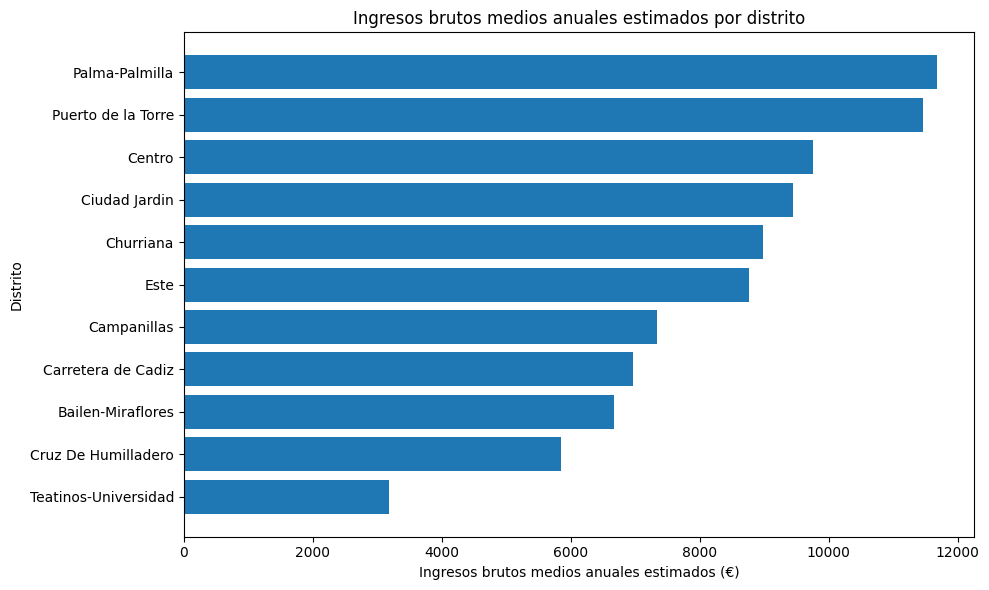

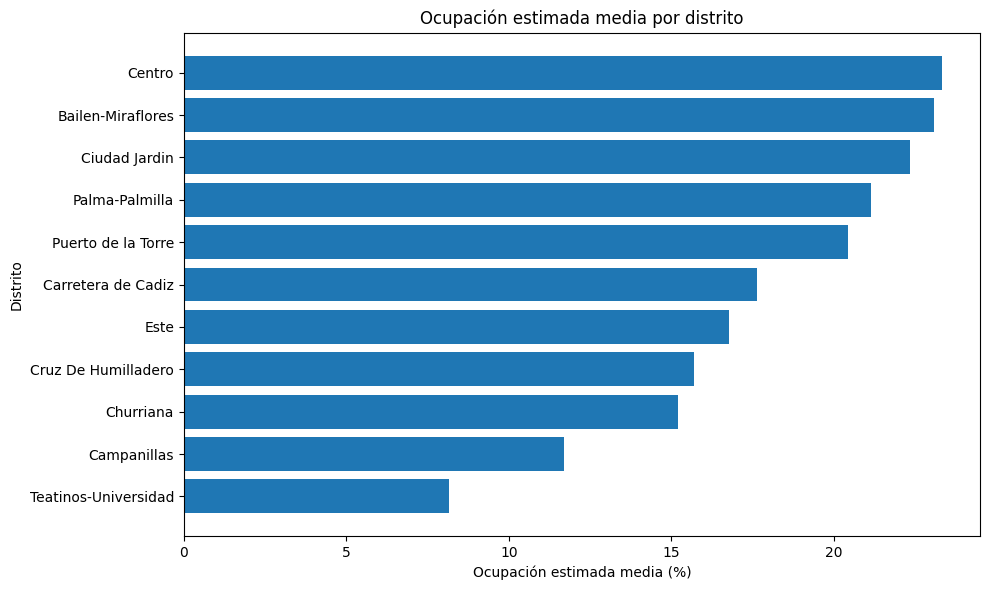

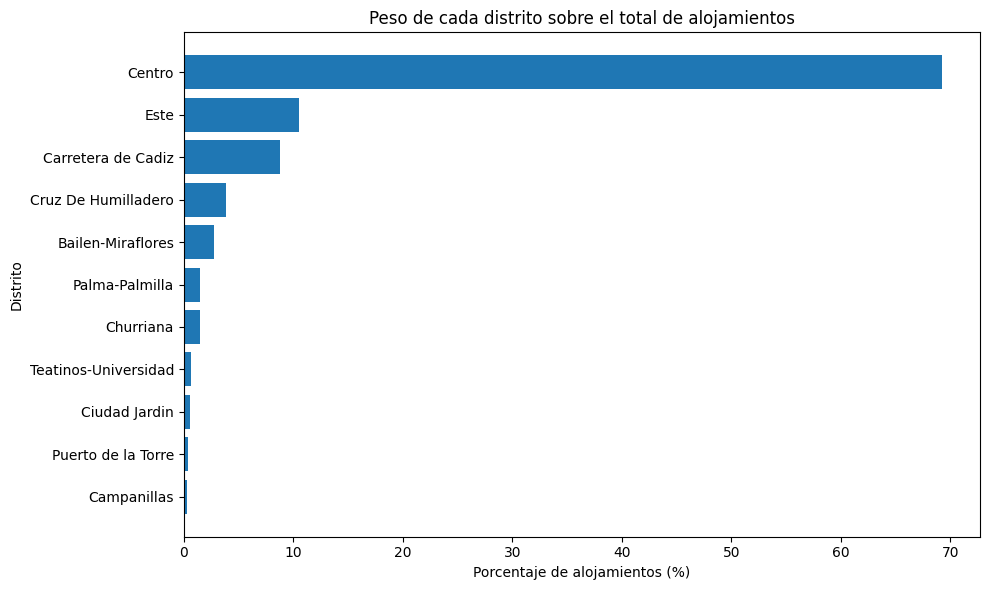

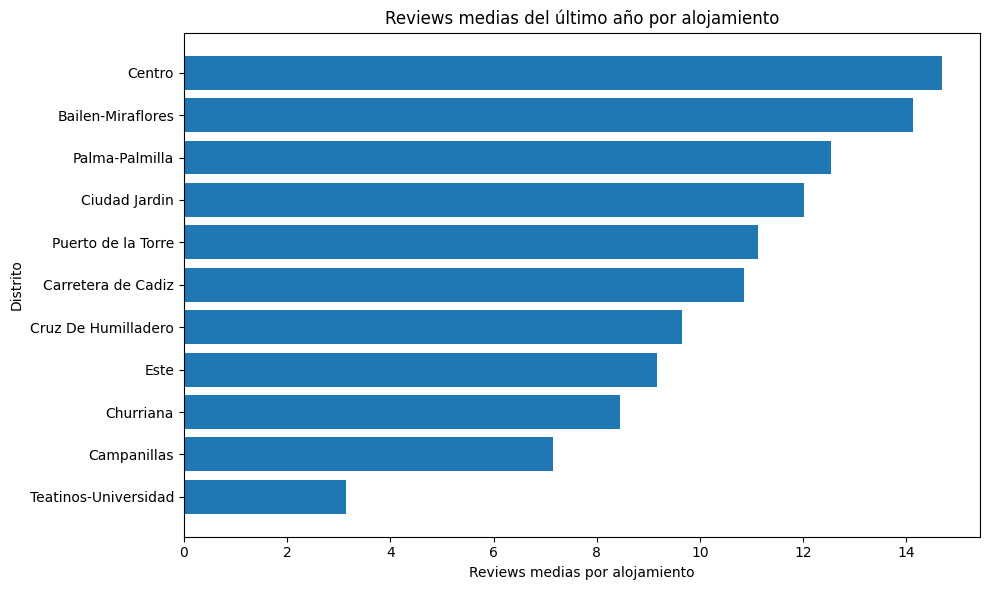

In [31]:
# ============================================================
# 7. VISUALIZACIÓN DE SEÑALES POR DISTRITO
# ============================================================
# En esta sección creamos gráficos sencillos a partir de la tabla
# senales_distritos.
#
# Estos gráficos no sustituyen al dashboard final en Power BI,
# pero ayudan a entender visualmente las diferencias entre distritos
# durante el análisis exploratorio.
# ============================================================


# ------------------------------------------------------------
# 1. Ingresos brutos medios anuales por distrito
# ------------------------------------------------------------
# Ordenamos la tabla por ingresos medios anuales para que el gráfico
# muestre los distritos de mayor a menor ingreso estimado.

grafico_ingresos = senales_distritos.sort_values(
    by="ingresos_medios_anuales",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    grafico_ingresos["distrito"],
    grafico_ingresos["ingresos_medios_anuales"]
)

plt.title("Ingresos brutos medios anuales estimados por distrito")
plt.xlabel("Ingresos brutos medios anuales estimados (€)")
plt.ylabel("Distrito")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Ocupación estimada media por distrito
# ------------------------------------------------------------
# Usamos el porcentaje aproximado de ocupación anual para que
# la métrica sea más fácil de interpretar.

grafico_ocupacion = senales_distritos.sort_values(
    by="ocupacion_media_pct",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    grafico_ocupacion["distrito"],
    grafico_ocupacion["ocupacion_media_pct"]
)

plt.title("Ocupación estimada media por distrito")
plt.xlabel("Ocupación estimada media (%)")
plt.ylabel("Distrito")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Peso de cada distrito sobre el total de alojamientos
# ------------------------------------------------------------
# Este gráfico permite ver claramente qué distritos concentran
# mayor volumen de oferta turística.

grafico_volumen = senales_distritos.sort_values(
    by="porcentaje_alojamientos",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    grafico_volumen["distrito"],
    grafico_volumen["porcentaje_alojamientos"]
)

plt.title("Peso de cada distrito sobre el total de alojamientos")
plt.xlabel("Porcentaje de alojamientos (%)")
plt.ylabel("Distrito")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Reviews medias del último año por distrito
# ------------------------------------------------------------
# Usamos la media de reviews por alojamiento para comparar actividad
# reciente de forma más justa entre distritos grandes y pequeños.

grafico_reviews = senales_distritos.sort_values(
    by="reviews_media_ultimo_anio",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    grafico_reviews["distrito"],
    grafico_reviews["reviews_media_ultimo_anio"]
)

plt.title("Reviews medias del último año por alojamiento")
plt.xlabel("Reviews medias por alojamiento")
plt.ylabel("Distrito")

plt.tight_layout()
plt.show()

### Conclusión de la visualización de señales por distrito

Los gráficos muestran que no existe un único distrito que destaque en todas las métricas, por lo que la comparación debe hacerse combinando varias señales: ingresos brutos estimados, ocupación, volumen de alojamientos y actividad reciente.

En ingresos brutos medios anuales estimados destacan `Palma-Palmilla` y `Puerto de la Torre`, seguidos de `Centro`, `Ciudad Jardín`, `Churriana` y `Este`. Sin embargo, algunos de estos distritos tienen un volumen reducido de alojamientos, por lo que sus medias pueden ser menos estables y deben interpretarse con cautela.

En ocupación estimada media destacan especialmente `Centro`, `Bailén-Miraflores`, `Ciudad Jardín`, `Palma-Palmilla` y `Puerto de la Torre`. Esto indica que no todos los distritos con mayores ingresos son necesariamente los que tienen mayor estabilidad de ocupación, por lo que conviene analizar ambas métricas juntas.

El gráfico de peso sobre el total de alojamientos muestra una concentración muy clara en `Centro`, que representa la mayor parte de la oferta turística del dataset. Esto sugiere que `Centro` es la zona con mayor madurez turística y datos más representativos, aunque también implica una competencia mucho más elevada.

En cuanto a reviews medias del último año por alojamiento, `Centro`, `Bailén-Miraflores`, `Palma-Palmilla` y `Ciudad Jardín` muestran buena actividad reciente. Esta métrica funciona como una señal indirecta de demanda, aunque no debe interpretarse como reservas reales.

En conjunto, `Centro` aparece como el distrito más sólido desde el punto de vista de volumen, ocupación y actividad turística reciente. Otros distritos como `Palma-Palmilla`, `Puerto de la Torre` o `Ciudad Jardín` muestran señales interesantes en ingresos u ocupación, pero al tener menor volumen de alojamientos requieren una interpretación más prudente.

Por tanto, el análisis visual refuerza que el dashboard no debe recomendar una zona únicamente por ingresos medios. La comparación debe combinar ingresos brutos estimados, ocupación, volumen de alojamientos, competencia y actividad reciente para ofrecer una primera criba más equilibrada.


## 8. Análisis estadístico de variables numéricas

Se analizan las principales variables numéricas del dataset para revisar medidas de tendencia central, dispersión y relación entre variables.

Este análisis permite entender mejor la distribución general de precios, ingresos, ocupación, disponibilidad y actividad reciente antes de diseñar las visualizaciones finales del dashboard.


,count,mean,std,min,25%,50%,75%,max,mediana
precio,"7,598.00",135.18,106.96,22.00,82.00,106.00,148.00,"1,000.00",106.00
ocupacion_estimada_365,"7,598.00",78.63,86.01,0.00,6.00,42.00,132.00,255.00,42.00
ingresos_estimados_365,"7,598.00","9,142.51","11,804.86",0.00,939.50,"4,512.00","13,860.00","149,940.00","4,512.00"
ingresos_estimados_mensuales,"7,598.00",761.88,983.74,0.00,78.29,376.00,"1,155.00","12,495.00",376.00
disponibilidad_365,"7,598.00",222.65,111.22,0.00,124.00,249.00,325.00,365.00,249.00
reviews_ultimo_anio,"7,598.00",13.31,17.11,0.00,1.00,6.00,20.00,194.00,6.00
reviews_por_mes,"7,598.00",1.33,1.43,0.00,0.28,0.86,1.98,22.30,0.86
capacidad,"7,598.00",4.14,1.99,1.00,3.00,4.00,5.00,16.00,4.00
dormitorios,"7,597.00",1.67,1.13,0.00,1.00,1.00,2.00,15.00,1.00


,precio,ocupacion_estimada_365,ingresos_estimados_365,ingresos_estimados_mensuales,disponibilidad_365,reviews_ultimo_anio,reviews_por_mes,capacidad,dormitorios
precio,1.00,-0.16,0.18,0.18,-0.05,-0.14,-0.16,0.45,0.41
ocupacion_estimada_365,-0.16,1.00,0.78,0.78,-0.06,0.91,0.78,-0.09,-0.05
ingresos_estimados_365,0.18,0.78,1.00,1.00,-0.03,0.70,0.61,0.19,0.22
ingresos_estimados_mensuales,0.18,0.78,1.00,1.00,-0.03,0.70,0.61,0.19,0.22
disponibilidad_365,-0.05,-0.06,-0.03,-0.03,1.00,-0.06,-0.04,0.02,-0.01
reviews_ultimo_anio,-0.14,0.91,0.70,0.70,-0.06,1.00,0.87,-0.08,-0.06
reviews_por_mes,-0.16,0.78,0.61,0.61,-0.04,0.87,1.00,-0.09,-0.06
capacidad,0.45,-0.09,0.19,0.19,0.02,-0.08,-0.09,1.00,0.81
dormitorios,0.41,-0.05,0.22,0.22,-0.01,-0.06,-0.06,0.81,1.00


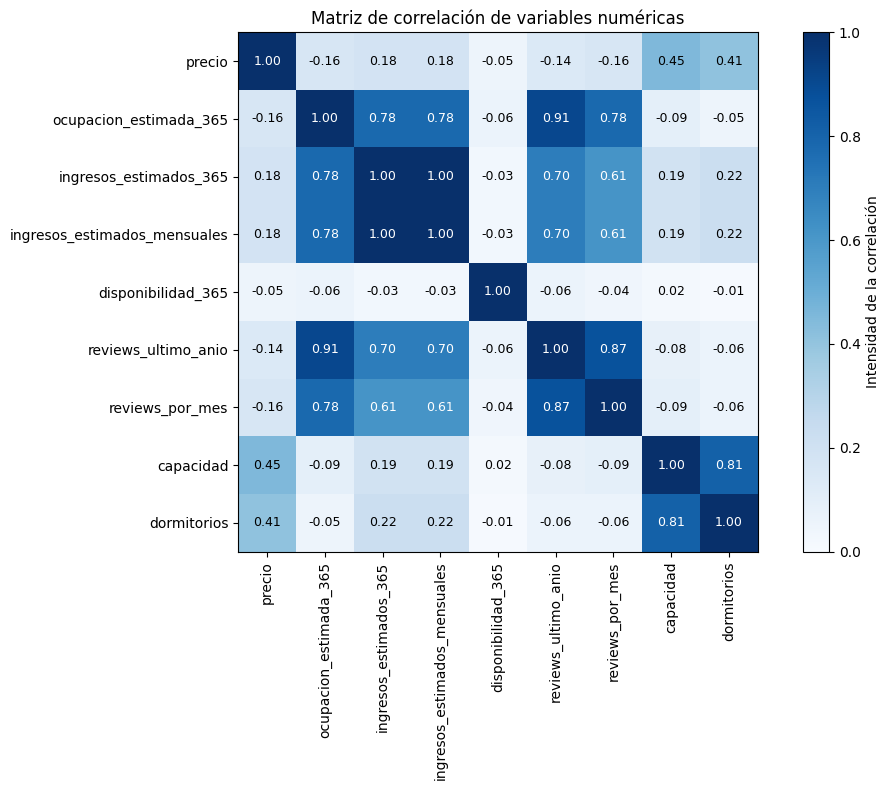

In [32]:
# ============================================================
# 8. ANÁLISIS ESTADÍSTICO DE VARIABLES NUMÉRICAS
# ============================================================
# En esta celda revisamos las variables numéricas principales
# del dataset limpio.
#
# Este análisis nos ayuda a cumplir una parte importante del briefing:
# incluir análisis estadístico dentro del proyecto.
#
# Analizamos:
# - medidas de tendencia central: media y mediana
# - medidas de dispersión: desviación típica, mínimo, máximo y cuartiles
# - correlaciones entre variables numéricas
# ============================================================


# ------------------------------------------------------------
# 1. Selección de variables numéricas relevantes
# ------------------------------------------------------------
# No usamos todas las columnas numéricas, solo las que aportan valor
# para el análisis de inversión turística.

variables_numericas = [
    "precio",
    "ocupacion_estimada_365",
    "ingresos_estimados_365",
    "ingresos_estimados_mensuales",
    "disponibilidad_365",
    "reviews_ultimo_anio",
    "reviews_por_mes",
    "capacidad",
    "dormitorios"
]


# ------------------------------------------------------------
# 2. Resumen estadístico
# ------------------------------------------------------------
# describe() calcula estadísticas básicas:
# - count: número de valores no nulos
# - mean: media
# - std: desviación típica
# - min: valor mínimo
# - 25%, 50%, 75%: cuartiles
# - max: valor máximo
#
# Transponemos la tabla con .T para que sea más fácil de leer.

resumen_estadistico = df[variables_numericas].describe().T


# ------------------------------------------------------------
# 3. Añadimos la mediana de forma explícita
# ------------------------------------------------------------
# Aunque describe() ya incluye el percentil 50%,
# creamos una columna llamada "mediana" para que sea más clara.

resumen_estadistico["mediana"] = df[variables_numericas].median()


# ------------------------------------------------------------
# 4. Redondeamos valores
# ------------------------------------------------------------
# Redondeamos a 2 decimales para mejorar la lectura.

resumen_estadistico = resumen_estadistico.round(2)


# Mostramos el resumen estadístico
display(resumen_estadistico)


# ------------------------------------------------------------
# 5. Matriz de correlación
# ------------------------------------------------------------
# La correlación mide la relación lineal entre variables.
#
# Valores cercanos a 1  → relación positiva fuerte.
# Valores cercanos a -1 → relación negativa fuerte.
# Valores cercanos a 0  → poca relación lineal.
#
# Importante:
# Correlación no significa causalidad.

matriz_correlacion = df[variables_numericas].corr().round(2)


# Mostramos la matriz de correlación como tabla
display(matriz_correlacion)


# ------------------------------------------------------------
# 6. Visualización de la matriz de correlación
# ------------------------------------------------------------
# Creamos un mapa de calor usando un solo color con distinta intensidad.
#
# Para el color usamos el valor absoluto de la correlación:
# - valores cercanos a 0 aparecen más claros
# - valores cercanos a 1 aparecen más oscuros
#
# Los números dentro de cada celda mantienen el valor real de correlación,
# incluyendo si la relación es positiva o negativa.
# ============================================================


# Usamos el valor absoluto solo para representar la intensidad del color
matriz_correlacion_intensidad = matriz_correlacion.abs()


plt.figure(figsize=(11, 8))


# Creamos el mapa de calor con una escala de un solo color
plt.imshow(
    matriz_correlacion_intensidad,
    cmap="Blues",
    vmin=0,
    vmax=1
)


# Añadimos los nombres de las variables en los ejes
plt.xticks(
    ticks=range(len(matriz_correlacion.columns)),
    labels=matriz_correlacion.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(matriz_correlacion.index)),
    labels=matriz_correlacion.index
)


# Añadimos los valores numéricos dentro de cada celda
# Esto ayuda a interpretar la correlación exacta.
for i in range(len(matriz_correlacion.index)):
    for j in range(len(matriz_correlacion.columns)):
        valor_real = matriz_correlacion.iloc[i, j]
        intensidad = matriz_correlacion_intensidad.iloc[i, j]
        
        # Si la celda es muy oscura, ponemos el texto en blanco.
        # Si la celda es clara, lo ponemos en negro.
        color_texto = "white" if intensidad > 0.6 else "black"
        
        plt.text(
            j,
            i,
            f"{valor_real:.2f}",
            ha="center",
            va="center",
            color=color_texto,
            fontsize=9
        )


# Barra lateral de intensidad
plt.colorbar(label="Intensidad de la correlación")


plt.title("Matriz de correlación de variables numéricas")

plt.tight_layout()
plt.show()

### Conclusión del análisis estadístico

El análisis estadístico muestra diferencias relevantes entre medias y medianas en variables como `precio`, `ocupacion_estimada_365`, `ingresos_estimados_365` y `reviews_ultimo_anio`, lo que indica distribuciones asimétricas. Por este motivo, en el dashboard será recomendable mostrar tanto medias como medianas cuando se analicen precios e ingresos.

La matriz de correlación muestra una relación fuerte entre `ocupacion_estimada_365` y `reviews_ultimo_anio`. Esto tiene sentido, ya que los alojamientos con mayor actividad suelen acumular más reviews recientes. No obstante, las reviews deben interpretarse como una señal indirecta de demanda, no como reservas reales.

También se observa una correlación fuerte entre `ocupacion_estimada_365` e `ingresos_estimados_365`, lo que indica que los ingresos estimados están muy relacionados con el nivel de ocupación. Además, `ingresos_estimados_365` e `ingresos_estimados_mensuales` tienen correlación perfecta porque una variable deriva directamente de la otra.

La relación entre `precio` e `ingresos_estimados_365` es débil, lo que sugiere que un precio más alto no implica necesariamente mayores ingresos estimados. Para el análisis de inversión turística, esto refuerza la importancia de combinar precio, ocupación, ingresos y actividad reciente, en lugar de analizar una sola variable de forma aislada.

Por último, `capacidad` y `dormitorios` presentan una correlación alta, algo esperable porque las viviendas con más dormitorios suelen alojar a más personas.


## 9. Distribución de precios, ingresos y ocupación

Se analizan visualmente las distribuciones de las variables principales del proyecto: precio por noche, ingresos brutos anuales estimados y ocupación estimada.

El objetivo es comprobar si estas variables presentan distribuciones equilibradas o si están concentradas en valores bajos con algunos alojamientos de valores más altos.


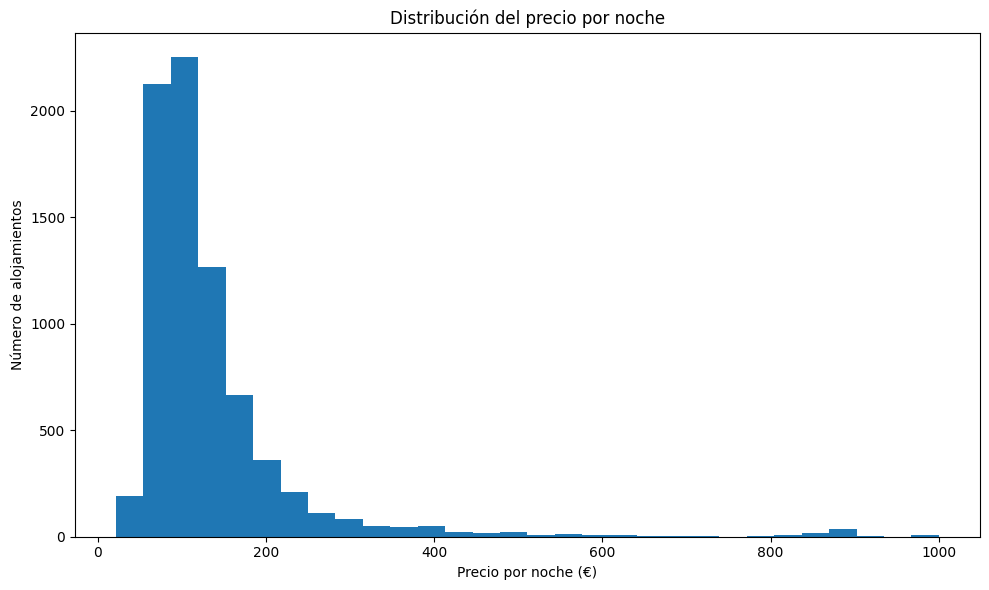

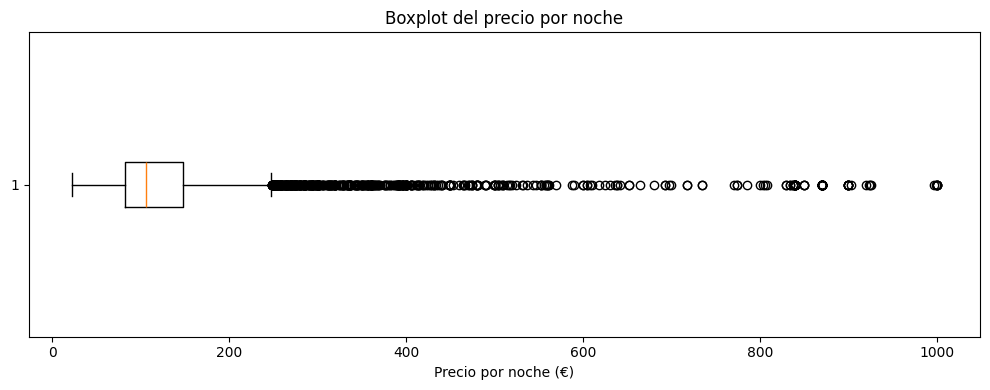

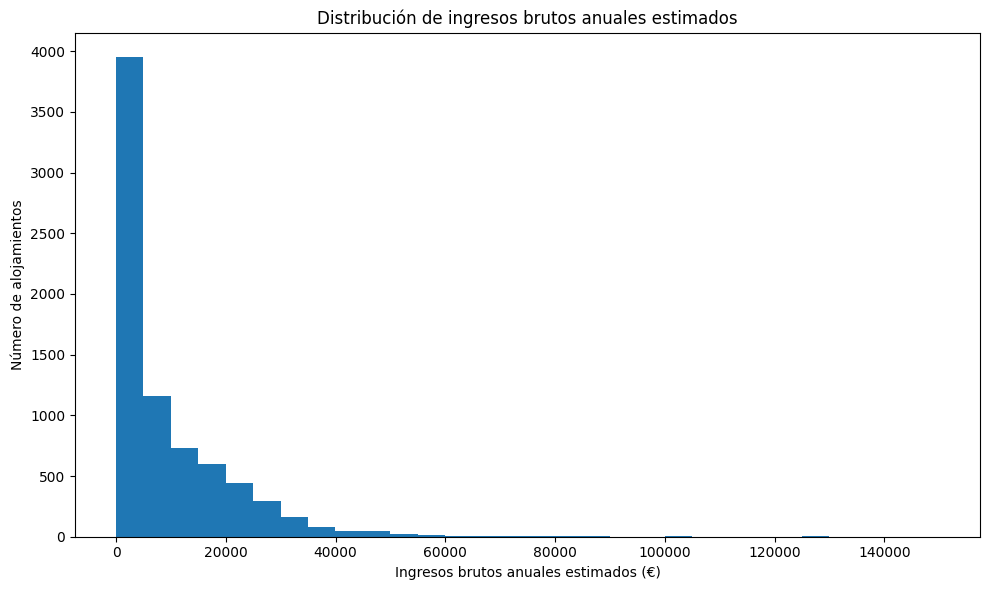

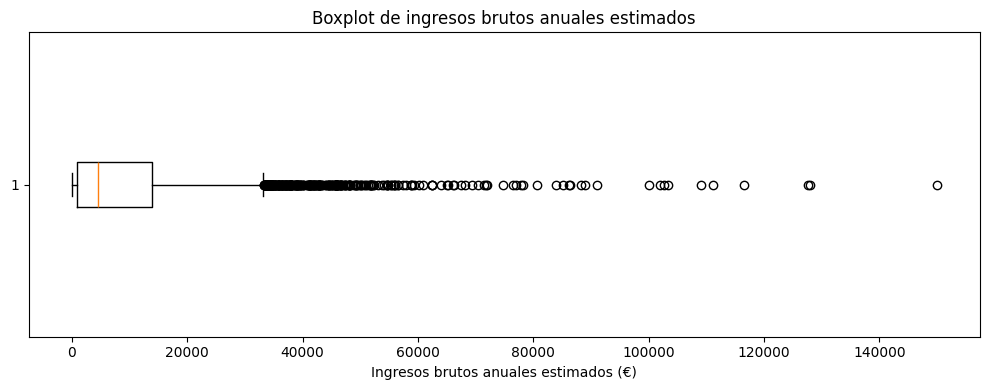

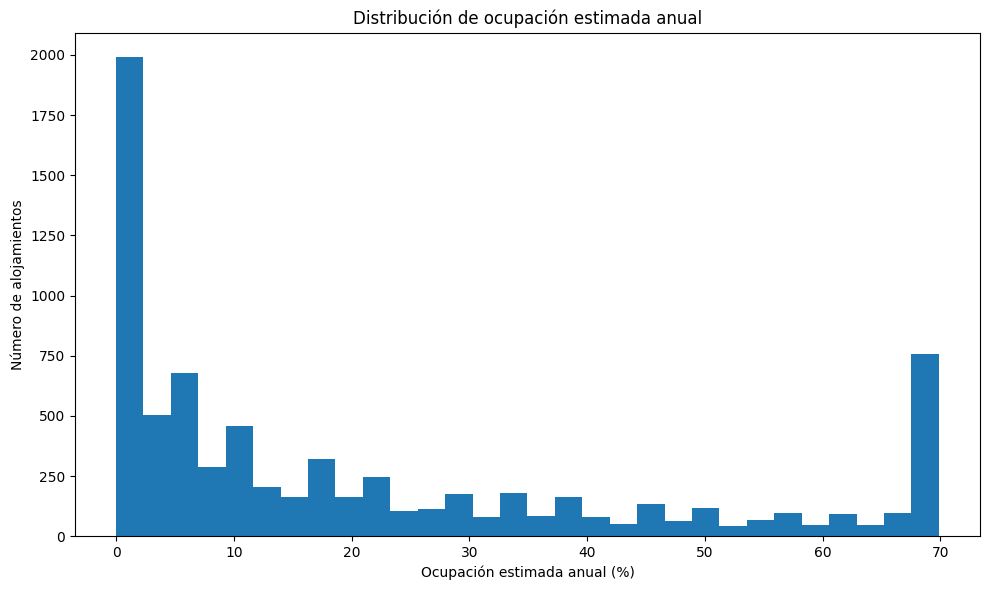

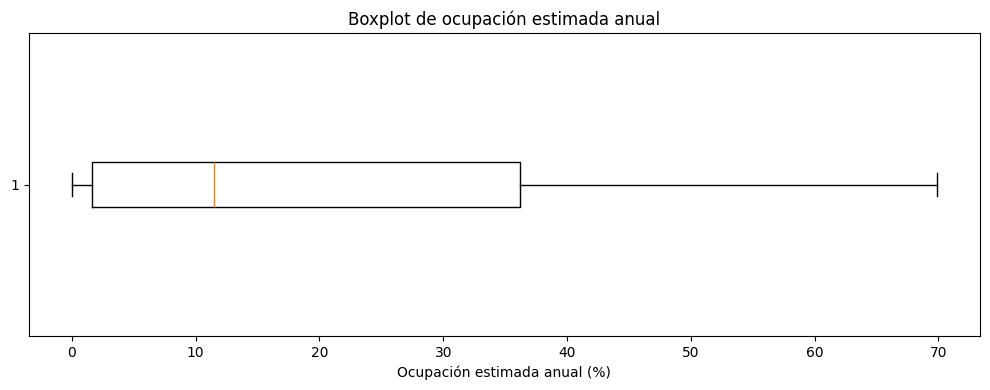

In [33]:
# ============================================================
# 9. DISTRIBUCIÓN DE PRECIOS, INGRESOS Y OCUPACIÓN
# ============================================================
# En esta sección visualizamos la distribución de las variables
# numéricas más importantes para el análisis.
#
# Analizamos:
# - precio por noche
# - ingresos brutos anuales estimados
# - ocupación estimada anual
#
# Estos gráficos ayudan a entender si las variables tienen
# distribuciones simétricas o si presentan concentración de valores
# en rangos bajos y algunos valores altos.
# ============================================================


# ------------------------------------------------------------
# 1. Histograma del precio por noche
# ------------------------------------------------------------
# El histograma muestra cómo se distribuyen los precios.
# Nos ayuda a ver en qué rangos se concentran la mayoría
# de alojamientos.

plt.figure(figsize=(10, 6))

plt.hist(
    df["precio"],
    bins=30
)

plt.title("Distribución del precio por noche")
plt.xlabel("Precio por noche (€)")
plt.ylabel("Número de alojamientos")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Boxplot del precio por noche
# ------------------------------------------------------------
# El boxplot permite ver:
# - la mediana
# - el rango intercuartílico
# - posibles valores altos dentro del dataset ya filtrado

plt.figure(figsize=(10, 4))

plt.boxplot(
    df["precio"],
    vert=False
)

plt.title("Boxplot del precio por noche")
plt.xlabel("Precio por noche (€)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Histograma de ingresos brutos anuales estimados
# ------------------------------------------------------------
# Revisamos cómo se distribuyen los ingresos brutos anuales.
# Esta variable es clave para comparar señales económicas,
# pero no representa rentabilidad neta.

plt.figure(figsize=(10, 6))

plt.hist(
    df["ingresos_estimados_365"],
    bins=30
)

plt.title("Distribución de ingresos brutos anuales estimados")
plt.xlabel("Ingresos brutos anuales estimados (€)")
plt.ylabel("Número de alojamientos")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Boxplot de ingresos brutos anuales estimados
# ------------------------------------------------------------
# El boxplot ayuda a visualizar la dispersión de ingresos.
# También permite ver si existen alojamientos con ingresos
# muy superiores a la mayoría.

plt.figure(figsize=(10, 4))

plt.boxplot(
    df["ingresos_estimados_365"],
    vert=False
)

plt.title("Boxplot de ingresos brutos anuales estimados")
plt.xlabel("Ingresos brutos anuales estimados (€)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Cálculo temporal de ocupación estimada en porcentaje
# ------------------------------------------------------------
# La variable ocupacion_estimada_365 representa días/noches
# estimados en un año.
#
# Para interpretarla mejor, calculamos una versión en porcentaje.
# No añadimos esta variable al DataFrame; solo la usamos aquí.

ocupacion_estimada_pct = df["ocupacion_estimada_365"] / 365 * 100


# ------------------------------------------------------------
# 6. Histograma de ocupación estimada
# ------------------------------------------------------------
# Este gráfico muestra cómo se distribuye la ocupación estimada
# en porcentaje anual aproximado.

plt.figure(figsize=(10, 6))

plt.hist(
    ocupacion_estimada_pct,
    bins=30
)

plt.title("Distribución de ocupación estimada anual")
plt.xlabel("Ocupación estimada anual (%)")
plt.ylabel("Número de alojamientos")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Boxplot de ocupación estimada
# ------------------------------------------------------------
# El boxplot permite ver la mediana, dispersión y posibles
# valores altos de ocupación estimada.

plt.figure(figsize=(10, 4))

plt.boxplot(
    ocupacion_estimada_pct,
    vert=False
)

plt.title("Boxplot de ocupación estimada anual")
plt.xlabel("Ocupación estimada anual (%)")

plt.tight_layout()
plt.show()

### Conclusión de la distribución de precios, ingresos y ocupación

Los gráficos muestran que las variables `precio` e `ingresos_estimados_365` presentan una distribución asimétrica hacia la derecha. La mayoría de alojamientos se concentra en rangos bajos o medios, mientras que existe un grupo menor con precios e ingresos bastante superiores.

En el caso del precio por noche, aunque en el notebook de preparación se eliminaron valores extremos superiores a 1.000 €, todavía aparecen alojamientos con precios altos dentro del rango conservado. Estos valores no se eliminan automáticamente, ya que pueden corresponder a viviendas con características especiales, como mayor capacidad, más dormitorios, mejor ubicación o tipologías más exclusivas.

La distribución de ingresos brutos anuales estimados también muestra una fuerte concentración en valores bajos, con algunos alojamientos que alcanzan ingresos mucho más elevados. Esto confirma que la media puede verse influida por alojamientos con resultados especialmente altos, por lo que conviene interpretar los ingresos junto con la mediana, la ocupación y la actividad reciente.

En la ocupación estimada anual se observa una barra muy alta cerca del 0%. Esto indica que una parte importante de los alojamientos tiene una ocupación estimada muy baja o nula. No se interpreta necesariamente como un error, sino como una señal de que no todos los alojamientos publicados tienen el mismo nivel de actividad turística.

El boxplot de ocupación muestra una gran dispersión: algunos alojamientos tienen muy poca actividad, mientras que otros alcanzan niveles de ocupación mucho más altos. Esto refuerza la idea de que el mercado turístico no se comporta de forma homogénea.

En conjunto, estos gráficos muestran que no basta con analizar una sola métrica. Para comparar distritos o detectar zonas interesantes, será necesario combinar precio, ingresos brutos estimados, ocupación y actividad reciente.


## 9.1. Comprobación de baja actividad: ocupación e ingresos

Después de observar una concentración elevada de alojamientos cerca del 0% de ocupación y en tramos bajos de ingresos, se realiza una comprobación numérica para cuantificar estos casos.

El objetivo es entender si la baja ocupación está relacionada con ingresos brutos estimados bajos o nulos, sin repetir el proceso de limpieza ni eliminar registros adicionales.

In [34]:
# ============================================================
# 9.1. COMPROBACIÓN DE BAJA ACTIVIDAD: OCUPACIÓN E INGRESOS
# ============================================================
# En los histogramas se observa:
# - una concentración alta de alojamientos cerca del 0% de ocupación
# - una concentración elevada de ingresos brutos estimados bajos
#
# En esta celda cuantificamos estos casos para interpretar mejor
# las distribuciones.
#
# No modificamos el dataset.
# Solo calculamos indicadores de apoyo para el análisis.
# ============================================================


# ------------------------------------------------------------
# 1. Cálculo de ocupación estimada en porcentaje
# ------------------------------------------------------------
# La columna ocupacion_estimada_365 representa días/noches
# estimados en un año.
#
# Para interpretarla como porcentaje anual aproximado,
# dividimos entre 365 y multiplicamos por 100.

ocupacion_pct = df["ocupacion_estimada_365"] / 365 * 100


# ------------------------------------------------------------
# 2. Alojamientos con ocupación igual a 0
# ------------------------------------------------------------
# Contamos los alojamientos que tienen ocupación estimada nula.

alojamientos_ocupacion_cero = (
    df["ocupacion_estimada_365"] == 0
).sum()

porcentaje_ocupacion_cero = (
    alojamientos_ocupacion_cero / len(df) * 100
)


# ------------------------------------------------------------
# 3. Alojamientos con ocupación muy baja
# ------------------------------------------------------------
# Consideramos ocupación muy baja aquellos alojamientos
# con menos del 5% de ocupación anual estimada.

alojamientos_ocupacion_muy_baja = (
    ocupacion_pct < 5
).sum()

porcentaje_ocupacion_muy_baja = (
    alojamientos_ocupacion_muy_baja / len(df) * 100
)


# ------------------------------------------------------------
# 4. Alojamientos con ingresos estimados igual a 0
# ------------------------------------------------------------
# Contamos cuántos alojamientos tienen ingresos brutos anuales
# estimados igual a 0.

alojamientos_ingresos_cero = (
    df["ingresos_estimados_365"] == 0
).sum()

porcentaje_ingresos_cero = (
    alojamientos_ingresos_cero / len(df) * 100
)


# ------------------------------------------------------------
# 5. Alojamientos con ingresos bajos
# ------------------------------------------------------------
# Usamos el percentil 25 como referencia del tramo bajo
# de ingresos.
#
# Esto significa que el 25% de los alojamientos tiene ingresos
# iguales o inferiores a este valor.

limite_ingresos_bajos = df["ingresos_estimados_365"].quantile(0.25)

alojamientos_ingresos_bajos = (
    df["ingresos_estimados_365"] <= limite_ingresos_bajos
).sum()

porcentaje_ingresos_bajos = (
    alojamientos_ingresos_bajos / len(df) * 100
)


# ------------------------------------------------------------
# 6. Relación entre ocupación nula e ingresos nulos
# ------------------------------------------------------------
# Comprobamos cuántos alojamientos tienen simultáneamente:
# - ocupación estimada igual a 0
# - ingresos estimados igual a 0

alojamientos_ocupacion_e_ingresos_cero = (
    (df["ocupacion_estimada_365"] == 0) &
    (df["ingresos_estimados_365"] == 0)
).sum()

porcentaje_ocupacion_e_ingresos_cero = (
    alojamientos_ocupacion_e_ingresos_cero / len(df) * 100
)


# ------------------------------------------------------------
# 7. Tabla resumen
# ------------------------------------------------------------
# Creamos una tabla para visualizar los resultados de forma clara.

resumen_baja_actividad = pd.DataFrame({
    "indicador": [
        "Ocupación estimada igual a 0",
        "Ocupación estimada inferior al 5% anual",
        "Ingresos estimados igual a 0",
        "Ingresos en el tramo bajo, percentil 25",
        "Ocupación e ingresos iguales a 0"
    ],
    "total_alojamientos": [
        alojamientos_ocupacion_cero,
        alojamientos_ocupacion_muy_baja,
        alojamientos_ingresos_cero,
        alojamientos_ingresos_bajos,
        alojamientos_ocupacion_e_ingresos_cero
    ],
    "porcentaje_sobre_total": [
        porcentaje_ocupacion_cero,
        porcentaje_ocupacion_muy_baja,
        porcentaje_ingresos_cero,
        porcentaje_ingresos_bajos,
        porcentaje_ocupacion_e_ingresos_cero
    ]
})


# Redondeamos el porcentaje para facilitar la lectura.

resumen_baja_actividad["porcentaje_sobre_total"] = (
    resumen_baja_actividad["porcentaje_sobre_total"].round(2)
)


# Mostramos la tabla resumen.

display(resumen_baja_actividad)


# ------------------------------------------------------------
# 8. Valor del percentil 25 de ingresos
# ------------------------------------------------------------
# Mostramos el límite usado para definir el tramo bajo de ingresos.

print("Límite de ingresos bajos, percentil 25:")
print(round(limite_ingresos_bajos, 2), "€")

,indicador,total_alojamientos,porcentaje_sobre_total
0,Ocupación estimada igual a 0,1367,17.99
1,Ocupación estimada inferior al 5% anual,2842,37.40
2,Ingresos estimados igual a 0,1367,17.99
3,"Ingresos en el tramo bajo, percentil 25",1900,25.01
4,Ocupación e ingresos iguales a 0,1367,17.99


Límite de ingresos bajos, percentil 25:
939.5 €


### Conclusión de la comprobación de baja actividad

La comprobación confirma que existe una parte relevante del dataset con baja actividad estimada según las variables disponibles.

En concreto, 1.367 alojamientos tienen una ocupación estimada igual a 0, lo que representa el 17,99% del total. Además, 2.842 alojamientos presentan una ocupación estimada inferior al 5% anual, equivalente al 37,40% del dataset.

También se observa que los 1.367 alojamientos con ocupación estimada igual a 0 tienen igualmente ingresos estimados iguales a 0. Esto explica la concentración de valores bajos en la distribución de ingresos.

Sin embargo, estos valores no deben interpretarse necesariamente como ausencia real de actividad turística. Es posible que algunos alojamientos reciban reservas a través de otras plataformas, agencias, webs propias u otros canales no reflejados en este dataset.

Por tanto, esta métrica debe entenderse como actividad estimada a partir de los datos disponibles, no como una medición completa de todas las reservas reales del mercado.

El percentil 25 de ingresos se sitúa en 939,50 €, lo que indica que una cuarta parte de los alojamientos presenta ingresos brutos anuales estimados iguales o inferiores a esa cantidad.

Para el dashboard, este hallazgo refuerza la importancia de interpretar la ocupación y los ingresos como señales aproximadas, combinándolas con otras variables como reviews recientes, volumen de alojamientos, precio y distrito.


## 9.2. Comprobación de valores altos en boxplots

Después de observar muchos puntos altos en los boxplots de `precio` e `ingresos_estimados_365`, se comprueba cuántos registros se consideran valores atípicos según la regla estadística del rango intercuartílico.

Esta comprobación no implica eliminar registros, sino entender si esos valores altos son numerosos y cómo pueden afectar a la interpretación de medias y distribuciones.

In [35]:
# ============================================================
# 9.2. COMPROBACIÓN DE VALORES ALTOS EN BOXPLOTS
# ============================================================
# En los boxplots de precio e ingresos aparecen muchos puntos altos.
#
# Un boxplot considera "valor atípico" cualquier dato que esté por encima de:
# Q3 + 1.5 * IQR
#
# Donde:
# - Q1 es el percentil 25
# - Q3 es el percentil 75
# - IQR es el rango intercuartílico: Q3 - Q1
#
# En esta celda calculamos esos límites y contamos cuántos alojamientos
# quedan por encima de ellos.
#
# Importante:
# No eliminamos estos registros.
# Solo cuantificamos el fenómeno para interpretarlo correctamente.
# ============================================================


# ------------------------------------------------------------
# 1. Variables que vamos a revisar
# ------------------------------------------------------------
# Revisamos las dos variables donde el boxplot muestra más puntos altos:
# - precio
# - ingresos_estimados_365

variables_outliers = [
    "precio",
    "ingresos_estimados_365"
]


# ------------------------------------------------------------
# 2. Creamos una lista para guardar los resultados
# ------------------------------------------------------------
# Aquí iremos guardando los cálculos de cada variable.

resultados_outliers = []


# ------------------------------------------------------------
# 3. Cálculo de límites y número de valores altos
# ------------------------------------------------------------
# Recorremos cada variable y calculamos:
# - Q1
# - Q3
# - IQR
# - límite superior del boxplot
# - número de valores por encima del límite
# - porcentaje sobre el total del dataset

for variable in variables_outliers:
    
    # Calculamos Q1 y Q3
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    
    # Calculamos el rango intercuartílico
    iqr = q3 - q1
    
    # Calculamos el límite superior del boxplot
    limite_superior = q3 + 1.5 * iqr
    
    # Contamos cuántos registros superan ese límite
    total_outliers_altos = (df[variable] > limite_superior).sum()
    
    # Calculamos el porcentaje sobre el total
    porcentaje_outliers_altos = total_outliers_altos / len(df) * 100
    
    # Guardamos los resultados
    resultados_outliers.append({
        "variable": variable,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_superior_boxplot": limite_superior,
        "valores_altos_boxplot": total_outliers_altos,
        "porcentaje_sobre_total": porcentaje_outliers_altos,
        "valor_maximo": df[variable].max()
    })


# ------------------------------------------------------------
# 4. Convertimos los resultados en tabla
# ------------------------------------------------------------

resumen_outliers_boxplot = pd.DataFrame(resultados_outliers)


# Redondeamos para facilitar la lectura
columnas_redondear = [
    "q1",
    "q3",
    "iqr",
    "limite_superior_boxplot",
    "porcentaje_sobre_total",
    "valor_maximo"
]

resumen_outliers_boxplot[columnas_redondear] = (
    resumen_outliers_boxplot[columnas_redondear].round(2)
)


# Mostramos la tabla resumen
display(resumen_outliers_boxplot)


# ------------------------------------------------------------
# 5. Muestra de alojamientos con ingresos más altos
# ------------------------------------------------------------
# Mostramos algunos casos altos para comprobar si parecen viviendas
# con más capacidad, más dormitorios o mayor actividad.

display(
    df[
        [
            "distrito",
            "nombre",
            "tipo_propiedad",
            "precio",
            "capacidad",
            "dormitorios",
            "ocupacion_estimada_365",
            "ingresos_estimados_365",
            "reviews_ultimo_anio"
        ]
    ]
    .sort_values(by="ingresos_estimados_365", ascending=False)
    .head(15)
)

,variable,q1,q3,iqr,limite_superior_boxplot,valores_altos_boxplot,porcentaje_sobre_total,valor_maximo
0,precio,82.00,148.00,66.00,247.00,551,7.25,"1,000.00"
1,ingresos_estimados_365,939.50,"13,860.00","12,920.50","33,240.75",303,3.99,"149,940.00"


,distrito,nombre,tipo_propiedad,precio,capacidad,dormitorios,ocupacion_estimada_365,ingresos_estimados_365,reviews_ultimo_anio
5546,Centro,Luxurious apartment in the heart of Málaga,Entire rental unit,588.00,3,1.00,255,"149,940.00",45
5427,Este,"WonderStays Villa Lucia , Pedregalejo, Málaga",Entire villa,735.00,12,6.00,174,"127,890.00",29
3505,Este,Villa with sea views in the heart of Malaga,Entire villa,638.00,12,6.00,200,"127,600.00",25
4535,Centro,Villa María Teresa Mar y Ciudad,Entire home,925.00,14,6.00,126,"116,550.00",21
4852,Este,Villa+pool 10min lopen naar Malaga’s beste str...,Entire villa,436.00,10,5.00,255,"111,180.00",42
1960,Puerto de la Torre,430m2👩‍👩‍👧‍👧HEATED POOL🏊‍♀️JACUZZI🥂CINE🎬PLAYGR...,Entire villa,428.00,15,5.00,255,"109,140.00",26
538,Centro,Málaga city center II,Entire rental unit,405.00,4,2.00,255,"103,275.00",4
545,Este,August Villa Málaga. Relax Playa Piscina Cowor...,Entire villa,450.00,15,8.00,228,"102,600.00",38
3495,Este,Villa con vistas espectaculares en Málaga,Entire villa,"1,000.00",14,7.00,102,"102,000.00",17
1645,Palma-Palmilla,Villa con preciosas vistas a Málaga,Entire villa,926.00,16,5.00,108,"100,008.00",9


### Conclusión de la comprobación de valores altos

La comprobación confirma que los puntos altos observados en los boxplots representan una parte limitada del dataset.

En el caso del `precio`, 551 alojamientos superan el límite superior del boxplot, lo que supone el 7,25% del total. Para `ingresos_estimados_365`, 303 alojamientos superan el límite superior, equivalente al 3,99% del dataset.

Estos valores no se interpretan automáticamente como errores. Al revisar los alojamientos con mayores ingresos estimados, se observa que muchos corresponden a viviendas con características especiales, como villas, mayor capacidad, más dormitorios, precios elevados u ocupaciones estimadas altas.

Por este motivo, no se eliminan más registros en esta fase. La decisión más prudente es mantener estos alojamientos dentro del análisis, pero interpretar las medias con cautela y apoyarse también en métricas más robustas como la mediana.

Esta comprobación refuerza que el mercado presenta una distribución desigual: la mayoría de alojamientos se concentra en valores bajos o medios, mientras que un grupo reducido alcanza precios o ingresos significativamente superiores.


## 10. Relación entre ocupación, ingresos, reviews y precio

Se analizan gráficamente algunas relaciones clave entre variables numéricas.

El objetivo es comprobar si los ingresos brutos estimados parecen estar más relacionados con la ocupación y la actividad reciente que con el precio por noche de forma aislada.


Correlación entre ocupación estimada e ingresos estimados:
0.78

Correlación entre reviews del último año y ocupación estimada:
0.91

Correlación entre precio e ingresos estimados:
0.18


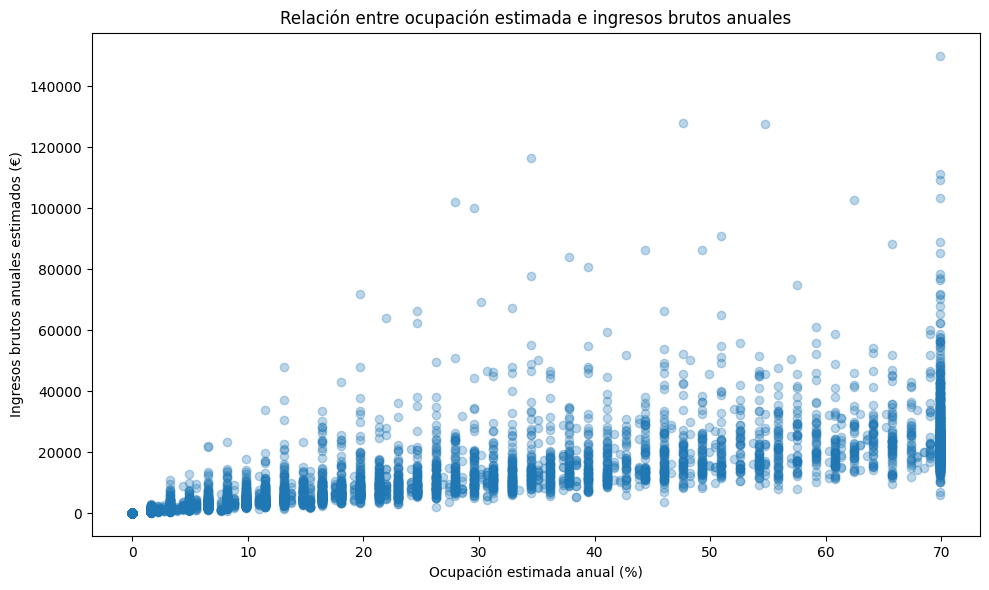

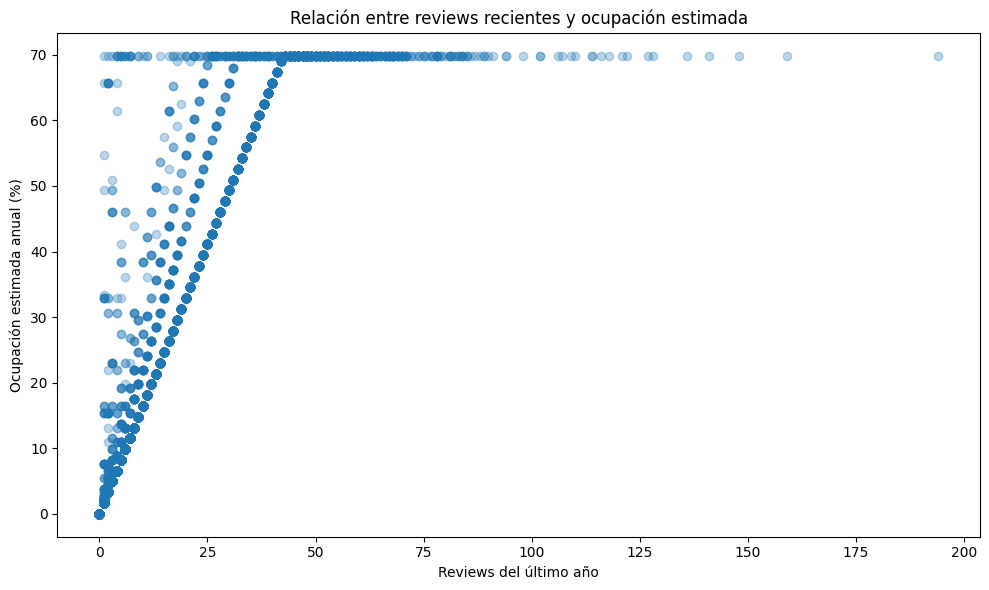

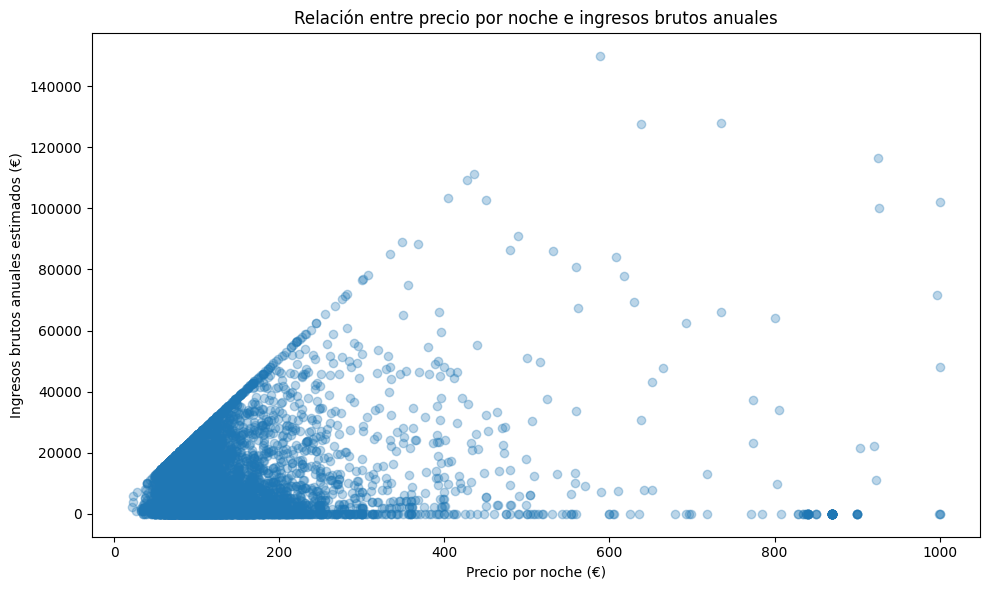

In [36]:
# ============================================================
# 10. RELACIÓN ENTRE OCUPACIÓN, INGRESOS, REVIEWS Y PRECIO
# ============================================================
# En esta sección usamos gráficos de dispersión para analizar
# relaciones entre variables clave.
#
# Los gráficos de dispersión permiten ver si dos variables tienden
# a moverse juntas.
#
# Analizamos:
# - ocupación estimada frente a ingresos estimados
# - reviews del último año frente a ocupación estimada
# - precio por noche frente a ingresos estimados
#
# No modificamos el dataset.
# Solo creamos variables temporales para visualizar mejor.
# ============================================================


# ------------------------------------------------------------
# 1. Ocupación estimada en porcentaje
# ------------------------------------------------------------
# Convertimos la ocupación estimada anual a porcentaje para que
# los gráficos sean más fáciles de interpretar.

ocupacion_pct = df["ocupacion_estimada_365"] / 365 * 100


# ------------------------------------------------------------
# 2. Correlaciones principales
# ------------------------------------------------------------
# Calculamos tres correlaciones concretas para acompañar
# la interpretación visual.
#
# Recordatorio:
# - valores cercanos a 1 indican relación positiva fuerte
# - valores cercanos a 0 indican relación débil
# - correlación no implica causalidad

corr_ocupacion_ingresos = df["ocupacion_estimada_365"].corr(
    df["ingresos_estimados_365"]
)

corr_reviews_ocupacion = df["reviews_ultimo_anio"].corr(
    df["ocupacion_estimada_365"]
)

corr_precio_ingresos = df["precio"].corr(
    df["ingresos_estimados_365"]
)


print("Correlación entre ocupación estimada e ingresos estimados:")
print(round(corr_ocupacion_ingresos, 2))

print("\nCorrelación entre reviews del último año y ocupación estimada:")
print(round(corr_reviews_ocupacion, 2))

print("\nCorrelación entre precio e ingresos estimados:")
print(round(corr_precio_ingresos, 2))


# ------------------------------------------------------------
# 3. Ocupación estimada vs ingresos estimados
# ------------------------------------------------------------
# Este gráfico permite comprobar si los alojamientos con mayor
# ocupación estimada tienden a generar mayores ingresos brutos.

plt.figure(figsize=(10, 6))

plt.scatter(
    ocupacion_pct,
    df["ingresos_estimados_365"],
    alpha=0.3
)

plt.title("Relación entre ocupación estimada e ingresos brutos anuales")
plt.xlabel("Ocupación estimada anual (%)")
plt.ylabel("Ingresos brutos anuales estimados (€)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Reviews del último año vs ocupación estimada
# ------------------------------------------------------------
# Las reviews recientes se usan como señal indirecta de actividad.
# Este gráfico ayuda a ver si los alojamientos con más reviews
# tienden a tener mayor ocupación estimada.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["reviews_ultimo_anio"],
    ocupacion_pct,
    alpha=0.3
)

plt.title("Relación entre reviews recientes y ocupación estimada")
plt.xlabel("Reviews del último año")
plt.ylabel("Ocupación estimada anual (%)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Precio por noche vs ingresos estimados
# ------------------------------------------------------------
# Este gráfico comprueba si un precio más alto implica
# necesariamente mayores ingresos brutos estimados.
#
# Según la matriz de correlación, esta relación era débil.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["precio"],
    df["ingresos_estimados_365"],
    alpha=0.3
)

plt.title("Relación entre precio por noche e ingresos brutos anuales")
plt.xlabel("Precio por noche (€)")
plt.ylabel("Ingresos brutos anuales estimados (€)")

plt.tight_layout()
plt.show()

### Conclusión de la relación entre variables clave

Los gráficos de dispersión muestran que los ingresos brutos estimados están mucho más relacionados con la ocupación estimada y la actividad reciente que con el precio por noche de forma aislada.

La relación entre ocupación estimada e ingresos estimados es fuerte, lo que indica que los alojamientos con mayor ocupación tienden a generar mayores ingresos brutos anuales. También se observa una relación muy alta entre reviews recientes y ocupación estimada, aunque esta relación debe interpretarse con cautela porque las reviews pueden formar parte de la propia estimación de actividad.

En cambio, la relación entre precio por noche e ingresos estimados es débil. Esto significa que tener un precio más alto no garantiza mayores ingresos, especialmente si el alojamiento tiene baja ocupación.

Por tanto, para comparar zonas o detectar oportunidades no es suficiente analizar el precio. El dashboard deberá combinar ingresos brutos estimados, ocupación, reviews recientes, volumen de alojamientos y nivel de competencia.

## 11. Análisis por dormitorios y nivel de precio

Se analizan las variables categóricas creadas en el notebook de preparación de datos para entender cómo se distribuyen los alojamientos según número de dormitorios y nivel de precio.

Este análisis ayuda a identificar qué tipos de vivienda predominan y qué perfiles pueden resultar más relevantes para el dashboard.

,tipo_dormitorios,total_alojamientos,porcentaje
0,1 dormitorio,3350,44.09
1,2 dormitorios,2216,29.17
2,3 o más dormitorios,1408,18.53
3,Sin información,624,8.21


,tipo_dormitorios,total_alojamientos,precio_mediano,ocupacion_media_365,ingresos_medios_anuales,reviews_media_ultimo_anio,ocupacion_media_pct
0,1 dormitorio,3350,92.00,80.73,"7,457.49",13.92,22.12
1,2 dormitorios,2216,118.00,79.46,"9,649.97",13.27,21.77
2,3 o más dormitorios,1408,161.00,71.60,"13,398.55",11.50,19.62
3,Sin información,624,87.00,80.20,"6,783.15",14.29,21.97


,nivel_precio,total_alojamientos,porcentaje
0,Alto,1913,25.18
1,Bajo,1905,25.07
2,Medio,1895,24.94
3,Premium,1885,24.81


,nivel_precio,total_alojamientos,precio_mediano,ocupacion_media_365,ingresos_medios_anuales,reviews_media_ultimo_anio,ocupacion_media_pct
1,Bajo,1905,71.00,99.09,"6,804.80",16.55,27.15
2,Medio,1895,93.00,85.54,"8,008.48",15.11,23.43
0,Alto,1913,123.00,74.70,"9,312.81",12.47,20.46
3,Premium,1885,196.00,54.99,"12,472.24",9.09,15.07


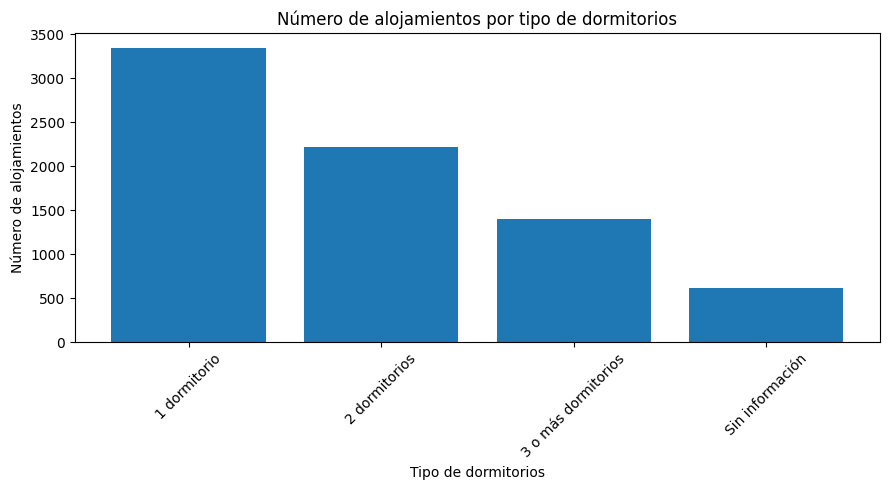

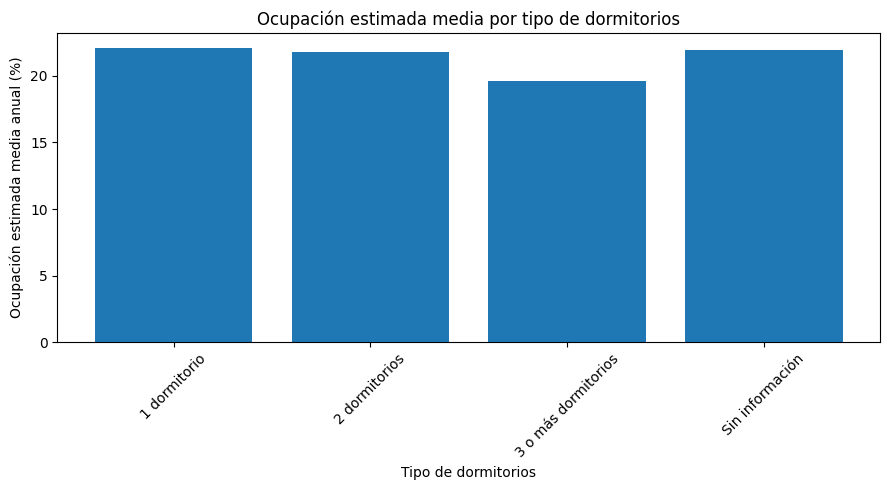

In [37]:
# ============================================================
# 11. ANÁLISIS POR DORMITORIOS Y NIVEL DE PRECIO
# ============================================================
# En esta sección analizamos dos variables derivadas:
# - tipo_dormitorios
# - nivel_precio
#
# Estas variables son útiles para crear filtros y segmentaciones
# en el dashboard de Power BI.
#
# No modificamos el dataset.
# Solo generamos tablas y gráficos de análisis.
# ============================================================


# ------------------------------------------------------------
# 1. Distribución por tipo de dormitorios
# ------------------------------------------------------------
# Calculamos cuántos alojamientos hay en cada categoría
# de dormitorios y qué porcentaje representan sobre el total.

analisis_dormitorios = (
    df["tipo_dormitorios"]
    .value_counts()
    .reset_index()
)

analisis_dormitorios.columns = [
    "tipo_dormitorios",
    "total_alojamientos"
]

analisis_dormitorios["porcentaje"] = (
    analisis_dormitorios["total_alojamientos"] / len(df) * 100
).round(2)

display(analisis_dormitorios)


# ------------------------------------------------------------
# 2. Métricas por tipo de dormitorios
# ------------------------------------------------------------
# Agrupamos por tipo de dormitorios para ver diferencias en:
# - precio mediano
# - ocupación media
# - ingresos medios
# - reviews medias recientes

metricas_dormitorios = (
    df
    .groupby("tipo_dormitorios")
    .agg(
        total_alojamientos=("id_alojamiento", "count"),
        precio_mediano=("precio", "median"),
        ocupacion_media_365=("ocupacion_estimada_365", "mean"),
        ingresos_medios_anuales=("ingresos_estimados_365", "mean"),
        reviews_media_ultimo_anio=("reviews_ultimo_anio", "mean")
    )
    .reset_index()
)


# Convertimos la ocupación media a porcentaje anual aproximado.

metricas_dormitorios["ocupacion_media_pct"] = (
    metricas_dormitorios["ocupacion_media_365"] / 365 * 100
)


# Redondeamos las columnas numéricas para mejorar la lectura.

columnas_redondear = [
    "precio_mediano",
    "ocupacion_media_365",
    "ocupacion_media_pct",
    "ingresos_medios_anuales",
    "reviews_media_ultimo_anio"
]

metricas_dormitorios[columnas_redondear] = (
    metricas_dormitorios[columnas_redondear].round(2)
)


# Ordenamos por número de alojamientos.

metricas_dormitorios = metricas_dormitorios.sort_values(
    by="total_alojamientos",
    ascending=False
)

display(metricas_dormitorios)


# ------------------------------------------------------------
# 3. Distribución por nivel de precio
# ------------------------------------------------------------
# Revisamos cuántos alojamientos hay en cada nivel de precio.

analisis_nivel_precio = (
    df["nivel_precio"]
    .value_counts()
    .reset_index()
)

analisis_nivel_precio.columns = [
    "nivel_precio",
    "total_alojamientos"
]

analisis_nivel_precio["porcentaje"] = (
    analisis_nivel_precio["total_alojamientos"] / len(df) * 100
).round(2)

display(analisis_nivel_precio)


# ------------------------------------------------------------
# 4. Métricas por nivel de precio
# ------------------------------------------------------------
# Comparamos los niveles de precio según ocupación, ingresos
# y actividad reciente.

metricas_nivel_precio = (
    df
    .groupby("nivel_precio")
    .agg(
        total_alojamientos=("id_alojamiento", "count"),
        precio_mediano=("precio", "median"),
        ocupacion_media_365=("ocupacion_estimada_365", "mean"),
        ingresos_medios_anuales=("ingresos_estimados_365", "mean"),
        reviews_media_ultimo_anio=("reviews_ultimo_anio", "mean")
    )
    .reset_index()
)


metricas_nivel_precio["ocupacion_media_pct"] = (
    metricas_nivel_precio["ocupacion_media_365"] / 365 * 100
)


metricas_nivel_precio[columnas_redondear] = (
    metricas_nivel_precio[columnas_redondear].round(2)
)


# Ordenamos manualmente los niveles para que tengan sentido lógico.

orden_precio = ["Bajo", "Medio", "Alto", "Premium"]

metricas_nivel_precio["nivel_precio"] = pd.Categorical(
    metricas_nivel_precio["nivel_precio"],
    categories=orden_precio,
    ordered=True
)

metricas_nivel_precio = metricas_nivel_precio.sort_values(
    by="nivel_precio"
)

display(metricas_nivel_precio)


# ------------------------------------------------------------
# 5. Gráfico: alojamientos por tipo de dormitorios
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    analisis_dormitorios["tipo_dormitorios"],
    analisis_dormitorios["total_alojamientos"]
)

plt.title("Número de alojamientos por tipo de dormitorios")
plt.xlabel("Tipo de dormitorios")
plt.ylabel("Número de alojamientos")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Gráfico: ocupación estimada media por tipo de dormitorios
# ------------------------------------------------------------
# Este gráfico muestra si las viviendas de 1, 2 o 3 o más dormitorios
# presentan diferencias en ocupación estimada.
#
# No representa reservas reales.
# Representa ocupación estimada anual calculada a partir de los datos
# disponibles en el dataset.

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_dormitorios["tipo_dormitorios"],
    metricas_dormitorios["ocupacion_media_pct"]
)

plt.title("Ocupación estimada media por tipo de dormitorios")
plt.xlabel("Tipo de dormitorios")
plt.ylabel("Ocupación estimada media anual (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Conclusión del análisis por dormitorios y nivel de precio

El análisis por dormitorios muestra que los alojamientos de 1 dormitorio son los más frecuentes en el dataset, representando el 44,09% del total. Les siguen los alojamientos de 2 dormitorios, con un 29,17%, y los de 3 o más dormitorios, con un 18,53%.

La ocupación estimada media es bastante similar entre los alojamientos de 1 y 2 dormitorios, ligeramente superior al 21% anual. Los alojamientos de 3 o más dormitorios presentan una ocupación algo menor, aunque generan los ingresos brutos medios anuales más altos. Esto sugiere que las viviendas más grandes pueden obtener más ingresos por su mayor precio y capacidad, aunque no necesariamente por tener más ocupación.

Por nivel de precio, los alojamientos `Premium` presentan los mayores ingresos brutos medios anuales, pero también la menor ocupación estimada media y menos reviews recientes. En cambio, los niveles de precio más bajos muestran mayor ocupación y más actividad reciente, aunque con menores ingresos medios.

Estos resultados refuerzan que el análisis no debe basarse solo en el precio o en el tamaño de la vivienda. Para el dashboard será útil permitir filtrar por número de dormitorios y nivel de precio, ya que cada perfil de alojamiento muestra comportamientos distintos en ocupación, ingresos y actividad reciente.


## 12. Sesgos, limitaciones y gobernanza del dato

Se identifican los principales sesgos y limitaciones del dataset para interpretar correctamente los resultados del análisis.

Esta sección ayuda a evitar conclusiones engañosas y servirá como base para incluir advertencias en el dashboard final.

In [38]:
# ============================================================
# 12. SESGOS, LIMITACIONES Y GOBERNANZA DEL DATO
# ============================================================
# En esta celda resumimos los principales aspectos que pueden
# afectar a la interpretación del análisis.
#
# No modificamos el dataset.
# Creamos una tabla explicativa que nos servirá para:
# - documentar el notebook
# - preparar el README
# - crear una sección de advertencias en Power BI
# ============================================================


# ------------------------------------------------------------
# 1. Creación de tabla resumen de sesgos y limitaciones
# ------------------------------------------------------------
# Cada fila recoge:
# - el aspecto revisado
# - la limitación principal
# - cómo debe interpretarse en el proyecto

sesgos_limitaciones = pd.DataFrame({
    "aspecto": [
        "Fuente de datos",
        "Canales de reserva",
        "Ocupación estimada",
        "Ingresos estimados",
        "Rentabilidad",
        "Estacionalidad",
        "Reviews",
        "Valores extremos",
        "Representatividad por distrito",
        "Normativa y licencias"
    ],
    
    "limitacion": [
        "El dataset procede de Airbnb / Inside Airbnb y no representa necesariamente todo el mercado turístico.",
        "Puede haber reservas realizadas por Booking, webs propias, agencias u otros canales no reflejados.",
        "La ocupación es una estimación anual, no una medición directa de reservas reales.",
        "Los ingresos son estimaciones brutas, no ingresos reales auditados.",
        "No se dispone de precio de compra, gastos, impuestos, hipoteca, reformas ni comisiones.",
        "El análisis trabaja con datos agregados anuales, no con detalle mensual.",
        "Las reviews son una señal indirecta de actividad, no equivalen exactamente a reservas.",
        "Existen alojamientos con precios e ingresos altos dentro del rango conservado.",
        "Algunos distritos tienen pocos alojamientos, por lo que sus medias pueden ser menos estables.",
        "No se analiza si cada alojamiento cumple normativa urbanística o licencia turística."
    ],
    
    "interpretacion_en_el_proyecto": [
        "El análisis se presenta como una primera criba de zonas, no como una visión completa del mercado.",
        "Una baja ocupación estimada en Airbnb no implica necesariamente ausencia real de actividad turística.",
        "Debe interpretarse como señal aproximada de actividad, no como dato exacto.",
        "Se usa el término ingresos brutos estimados, evitando hablar de beneficio neto.",
        "No se calcula rentabilidad real ni ROI.",
        "La visión anual es útil para comparar distritos, pero no permite analizar estabilidad mensual.",
        "Se combinan con ocupación, ingresos y volumen de alojamientos.",
        "Se usan medianas y comprobaciones de outliers para evitar conclusiones distorsionadas.",
        "Los distritos con menor volumen se interpretan con más cautela.",
        "El dashboard no sustituye una revisión legal previa a una inversión real."
    ]
})


# ------------------------------------------------------------
# 2. Visualización de la tabla
# ------------------------------------------------------------
# Como las columnas contienen textos largos, usamos HTML para que
# el contenido se vea completo y con salto de línea dentro de cada celda.

from IPython.display import HTML, display

display(
    HTML(
        sesgos_limitaciones.to_html(
            index=False,
            escape=False
        ).replace(
            "<table border=\"1\" class=\"dataframe\">",
            """
            <table border="1" class="dataframe" 
            style="border-collapse:collapse; width:100%; table-layout:fixed;">
            """
        ).replace(
            "<td>",
            "<td style='white-space:normal; text-align:left; vertical-align:top; padding:8px;'>"
        ).replace(
            "<th>",
            "<th style='white-space:normal; text-align:left; vertical-align:top; padding:8px;'>"
        )
    )
)

aspecto,limitacion,interpretacion_en_el_proyecto
Fuente de datos,El dataset procede de Airbnb / Inside Airbnb y no representa necesariamente todo el mercado turístico.,"El análisis se presenta como una primera criba de zonas, no como una visión completa del mercado."
Canales de reserva,"Puede haber reservas realizadas por Booking, webs propias, agencias u otros canales no reflejados.",Una baja ocupación estimada en Airbnb no implica necesariamente ausencia real de actividad turística.
Ocupación estimada,"La ocupación es una estimación anual, no una medición directa de reservas reales.","Debe interpretarse como señal aproximada de actividad, no como dato exacto."
Ingresos estimados,"Los ingresos son estimaciones brutas, no ingresos reales auditados.","Se usa el término ingresos brutos estimados, evitando hablar de beneficio neto."
Rentabilidad,"No se dispone de precio de compra, gastos, impuestos, hipoteca, reformas ni comisiones.",No se calcula rentabilidad real ni ROI.
Estacionalidad,"El análisis trabaja con datos agregados anuales, no con detalle mensual.","La visión anual es útil para comparar distritos, pero no permite analizar estabilidad mensual."
Reviews,"Las reviews son una señal indirecta de actividad, no equivalen exactamente a reservas.","Se combinan con ocupación, ingresos y volumen de alojamientos."
Valores extremos,Existen alojamientos con precios e ingresos altos dentro del rango conservado.,Se usan medianas y comprobaciones de outliers para evitar conclusiones distorsionadas.
Representatividad por distrito,"Algunos distritos tienen pocos alojamientos, por lo que sus medias pueden ser menos estables.",Los distritos con menor volumen se interpretan con más cautela.
Normativa y licencias,No se analiza si cada alojamiento cumple normativa urbanística o licencia turística.,El dashboard no sustituye una revisión legal previa a una inversión real.


### Conclusión sobre sesgos y gobernanza

El análisis permite comparar distritos de Málaga a partir de señales turísticas y económicas visibles en el dataset, pero no debe interpretarse como una recomendación directa de compra.

Los datos permiten analizar precios, ocupación estimada, ingresos brutos estimados, reviews y volumen de alojamientos, pero no incluyen información clave para calcular rentabilidad real, como precio de adquisición, gastos, fiscalidad, financiación, normativa urbanística o reservas procedentes de otros canales.

Por este motivo, el dashboard debe presentarse como una herramienta de apoyo para detectar zonas que merecen un análisis posterior, no como una herramienta definitiva de decisión inmobiliaria.

Estas advertencias deberán aparecer también en el dashboard final para que una audiencia no técnica entienda correctamente el alcance del análisis.

## 13. Conclusiones del análisis exploratorio

En esta sección se resumen los principales hallazgos del análisis exploratorio y se identifican las métricas que serán más útiles para construir el dashboard en Power BI.

### Principales hallazgos

El análisis muestra que el mercado de alojamientos turísticos completos en Málaga está muy concentrado en el distrito `Centro`, que reúne la mayor parte de la oferta disponible en el dataset.

`Centro` no siempre aparece como el distrito con mayores ingresos brutos medios anuales, pero sí destaca por combinar alto volumen de alojamientos, ocupación estimada elevada y mucha actividad reciente medida a través de reviews. Esto lo convierte en una zona clave para el análisis, aunque también implica una competencia muy alta.

Algunos distritos fuera del centro, como `Palma-Palmilla`, `Puerto de la Torre`, `Ciudad Jardín`, `Churriana` o `Este`, muestran señales interesantes en ingresos brutos estimados u ocupación. Sin embargo, varios de estos distritos tienen un volumen de alojamientos mucho menor, por lo que sus medias deben interpretarse con más cautela.

El análisis estadístico muestra que variables como `precio` e `ingresos_estimados_365` presentan distribuciones asimétricas. Esto significa que existen alojamientos con valores altos que pueden elevar la media. Por ese motivo, para el dashboard será recomendable mostrar tanto medias como medianas, especialmente en precios e ingresos.

La ocupación estimada y las reviews recientes están fuertemente relacionadas con los ingresos brutos estimados. En cambio, el precio por noche tiene una relación más débil con los ingresos. Esto indica que un precio alto no garantiza necesariamente mejores resultados si no va acompañado de ocupación y actividad turística.

El análisis por dormitorios muestra que los alojamientos de 1 y 2 dormitorios son los más frecuentes y mantienen una ocupación estimada ligeramente superior. Los alojamientos de 3 o más dormitorios generan mayores ingresos medios, pero con menor ocupación estimada.

Por nivel de precio, los alojamientos `Premium` generan mayores ingresos brutos medios, pero tienen menor ocupación estimada y menos reviews recientes. Esto refuerza la idea de que cada perfil de alojamiento tiene un comportamiento distinto.

En conjunto, el análisis confirma que no se debe recomendar una zona únicamente por una métrica aislada. Para comparar distritos de forma equilibrada será necesario combinar ingresos brutos estimados, ocupación, precio, volumen de alojamientos, actividad reciente y nivel de competencia.

### Implicaciones para el dashboard

El dashboard deberá presentar el análisis como una herramienta de apoyo para una primera criba de zonas, no como una recomendación directa de compra.

Las visualizaciones principales deberían permitir comparar distritos según:

- ingresos brutos anuales estimados;
- ocupación estimada;
- precio medio y mediano;
- volumen de alojamientos;
- reviews recientes;
- nivel de competencia;
- tipo de dormitorios;
- nivel de precio.

También será importante incluir una sección de advertencias para explicar que los ingresos son brutos estimados, que la ocupación no representa reservas reales exactas y que no se calcula rentabilidad neta ni retorno de inversión.

La narrativa principal del dashboard será identificar qué distritos muestran mejores señales para estudiar una posible inversión en vivienda turística, combinando varias métricas y evitando conclusiones basadas en un único indicador.